# Coffee Shop Chain Sales Performance Analysis
## Phase 2: Data Profiling & Exploratory Data Analysis (EDA)
**Dataset:** Coffee Shop Sales (Jan–Jun 2023) | 149,116 transactions | 3 NYC locations

### 2.1 Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv(r'C:\project\eda\myenv\data\Project.csv')
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (149116, 18)


### 2.2 Initial Inspection
We examine the structure, data types, and a statistical summary of the dataset.

In [2]:
# Basic structure
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== FIRST 5 ROWS ===")
df.head()

=== DATA TYPES ===
transaction_id        int64
transaction_date        str
transaction_time        str
store_id              int64
store_location          str
product_id            int64
transaction_qty       int64
unit_price          float64
Total_Bill          float64
product_category        str
product_type            str
product_detail          str
Size                    str
Month Name              str
Day Name                str
Hour                  int64
Month                 int64
Day of Week           int64
dtype: object

=== FIRST 5 ROWS ===


,transaction_id,transaction_date,transaction_time,store_id,store_location,product_id,transaction_qty,unit_price,Total_Bill,product_category,product_type,product_detail,Size,Month Name,Day Name,Hour,Month,Day of Week
0,114301,01-06-2023,11:33:29,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Thursday,11,6,3
1,115405,02-06-2023,11:18:24,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,11,6,4
2,115478,02-06-2023,12:02:45,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,12,6,4
3,116288,02-06-2023,19:39:47,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Friday,19,6,4
4,116714,03-06-2023,12:24:57,3,Astoria,45,1,3.0,3.0,Tea,Brewed herbal tea,Peppermint,Large,June,Saturday,12,6,5


In [3]:
# Statistical summary of numeric columns
print("=== DESCRIPTIVE SUMMARY ===")
df.describe().round(2)

=== DESCRIPTIVE SUMMARY ===


,transaction_id,store_id,product_id,transaction_qty,unit_price,Total_Bill,Hour,Month,Day of Week
count,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00,149116.00
mean,74737.37,5.34,47.92,1.44,3.38,4.69,11.74,3.99,2.98
std,43153.60,2.07,17.93,0.54,2.66,4.23,3.76,1.67,2.00
min,1.00,3.00,1.00,1.00,0.80,0.80,6.00,1.00,0.00
25%,37335.75,3.00,33.00,1.00,2.50,3.00,9.00,3.00,1.00
50%,74727.50,5.00,47.00,1.00,3.00,3.75,11.00,4.00,3.00
75%,112094.25,8.00,60.00,2.00,3.75,6.00,15.00,5.00,5.00
max,149456.00,8.00,87.00,8.00,45.00,360.00,20.00,6.00,6.00


In [4]:
# Full info overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  str    
 2   transaction_time  149116 non-null  str    
 3   store_id          149116 non-null  int64  
 4   store_location    149116 non-null  str    
 5   product_id        149116 non-null  int64  
 6   transaction_qty   149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   Total_Bill        149116 non-null  float64
 9   product_category  149116 non-null  str    
 10  product_type      149116 non-null  str    
 11  product_detail    149116 non-null  str    
 12  Size              149116 non-null  str    
 13  Month Name        149116 non-null  str    
 14  Day Name          149116 non-null  str    
 15  Hour              149116 non-null  int64  
 16  Month             149116 non-nu

### 2.3 Missing Value Analysis
We check for null values across all columns and decide how to handle them.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found. Dataset is complete.")
else:
    print(missing_df)

No missing values found. Dataset is complete.


In [6]:
# Since there are no missing values, we confirm with a summary table instead
completeness = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.notnull().sum().values,
    'Missing Count': df.isnull().sum().values,
    'Complete %': (df.notnull().sum().values / len(df) * 100).round(2)
})

print("=== DATASET COMPLETENESS REPORT ===")
print(completeness.to_string(index=False))
print(f"\nAll {len(df.columns)} columns are 100% complete. No treatment required.")

=== DATASET COMPLETENESS REPORT ===
          Column  Non-Null Count  Missing Count  Complete %
  transaction_id          149116              0       100.0
transaction_date          149116              0       100.0
transaction_time          149116              0       100.0
        store_id          149116              0       100.0
  store_location          149116              0       100.0
      product_id          149116              0       100.0
 transaction_qty          149116              0       100.0
      unit_price          149116              0       100.0
      Total_Bill          149116              0       100.0
product_category          149116              0       100.0
    product_type          149116              0       100.0
  product_detail          149116              0       100.0
            Size          149116              0       100.0
      Month Name          149116              0       100.0
        Day Name          149116              0       100.0
    

### 2.4 Data Type Corrections
Convert date and time columns to proper formats for time-series analysis.

In [7]:
# Convert date and time to proper types
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True, format='%d-%m-%Y')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

# Verify
print(df[['transaction_date', 'transaction_time']].dtypes)
print(df[['transaction_date', 'transaction_time']].head())

transaction_date    datetime64[us]
transaction_time            object
dtype: object
  transaction_date transaction_time
0       2023-06-01         11:33:29
1       2023-06-02         11:18:24
2       2023-06-02         12:02:45
3       2023-06-02         19:39:47
4       2023-06-03         12:24:57


### 2.5 Outlier Detection
We use the IQR method to detect outliers in the three key numeric variables:
`transaction_qty`, `unit_price`, and `Total_Bill`.

In [8]:
numeric_cols = ['transaction_qty', 'unit_price', 'Total_Bill']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%) | Lower: {lower:.2f} | Upper: {upper:.2f}")

transaction_qty: 36 outliers (0.02%) | Lower: -0.50 | Upper: 3.50
unit_price: 4212 outliers (2.82%) | Lower: 0.62 | Upper: 5.62
Total_Bill: 3273 outliers (2.19%) | Lower: -1.50 | Upper: 10.50


In [9]:
# Z-score outlier check (supplementary method)
from scipy import stats

print("=== Z-SCORE OUTLIER CHECK (threshold: |z| > 3) ===")
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers_z = df[z_scores > 3]
    print(f"{col}: {len(outliers_z)} outliers ({len(outliers_z)/len(df)*100:.2f}%)")

=== Z-SCORE OUTLIER CHECK (threshold: |z| > 3) ===
transaction_qty: 36 outliers (0.02%)
unit_price: 2514 outliers (1.69%)
Total_Bill: 1545 outliers (1.04%)


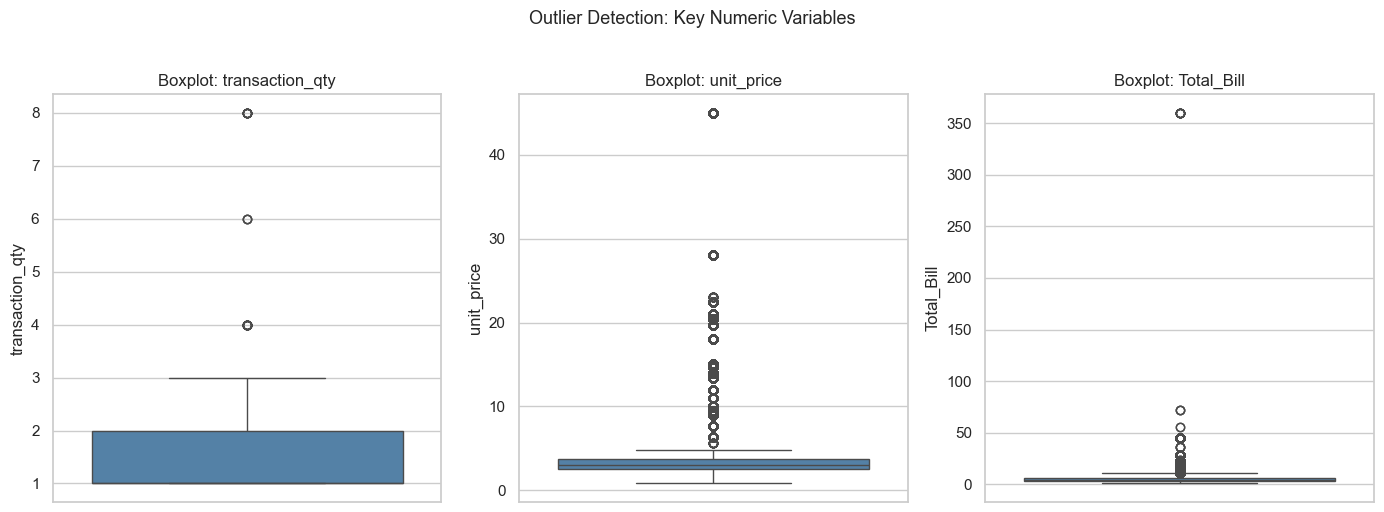

In [10]:
# Boxplots to visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection: Key Numeric Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Transaction quantity outliers (only 36, or 0.02%) are negligible and likely represent bulk or catering orders, safe to keep in the dataset. Unit price outliers (2.82%) reflect premium products like specialty beans or merchandise, which are legitimate data points. Total_Bill outliers (2.19%) are driven by high-unit-price items rather than data errors.

### 2.6 Distribution Analysis
We examine the distribution shape of all numeric variables using histograms and KDE plots.

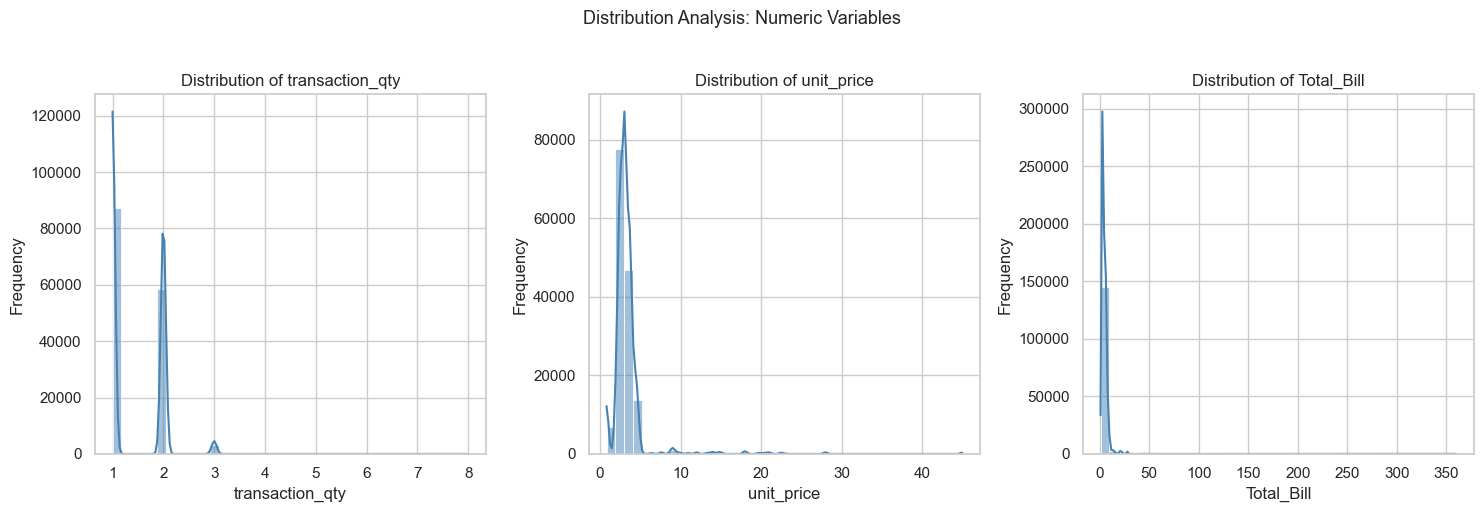

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution Analysis: Numeric Variables', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** All three numeric variables are right-skewed, with Total_Bill showing an extreme skewness of 41.75, meaning the overwhelming majority of transactions are small-ticket purchases under $10, with a tiny fraction of high-value orders pulling the mean upward. This is typical of a high-frequency café environment. The median ($3.75) is a more reliable measure of the typical transaction than the mean ($4.69).

In [12]:
# Skewness and kurtosis
print("=== SKEWNESS & KURTOSIS ===")
for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col}: Skewness = {skew:.3f} | Kurtosis = {kurt:.3f}")

=== SKEWNESS & KURTOSIS ===
transaction_qty: Skewness = 0.800 | Kurtosis = 0.824
unit_price: Skewness = 8.455 | Kurtosis = 98.919
Total_Bill: Skewness = 41.746 | Kurtosis = 3359.755


**Note on skewness:** A skewness above 1.0 is considered highly skewed. Total_Bill at 41.75 and unit_price at 8.46 are both extreme, this is explained by a small number of premium products (e.g., coffee beans, merchandise) that are priced far above the typical $2–$5 drink. These are not errors; they represent a genuinely different purchase type.

### 2.7 Correlation Matrix
We examine linear relationships between the numeric variables.

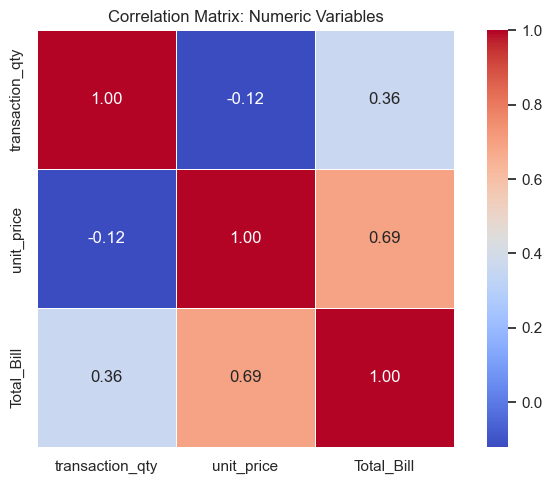

                 transaction_qty  unit_price  Total_Bill
transaction_qty             1.00       -0.12        0.36
unit_price                 -0.12        1.00        0.69
Total_Bill                  0.36        0.69        1.00


In [13]:
corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix: Numeric Variables')
plt.tight_layout()
plt.show()

print(corr_matrix)

**Interpretation:** Unit price has the strongest relationship with Total_Bill (r = 0.69), meaning what drives a higher bill is primarily *what* a customer orders, not *how many* items they buy. Transaction quantity has a weaker positive relationship (r = 0.36), suggesting most customers order 1–2 items regardless of price. The slight negative correlation between unit_price and transaction_qty (r = -0.12) hints that customers ordering premium-priced items tend to buy fewer units.

### 2.8 Categorical Variable Overview
A quick look at the unique values and distribution of key categorical columns.

In [14]:
cat_cols = ['store_location', 'product_category', 'product_type', 'Size']

for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts())


=== STORE_LOCATION ===
store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64

=== PRODUCT_CATEGORY ===
product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

=== PRODUCT_TYPE ===
product_type
Brewed Chai tea          17183
Gourmet brewed coffee    16912
Barista Espresso         16403
Hot chocolate            11468
Brewed Black tea         11350
Brewed herbal tea        11245
Scone                    10173
Organic brewed coffee     8489
Drip coffee               8477
Premium brewed coffee     8135
Pastry                    6912
Biscotti                  5711
Brewed Green tea          5671
Regular syrup             4979
Sugar free syrup          1811
Housewares                 526
Chai tea

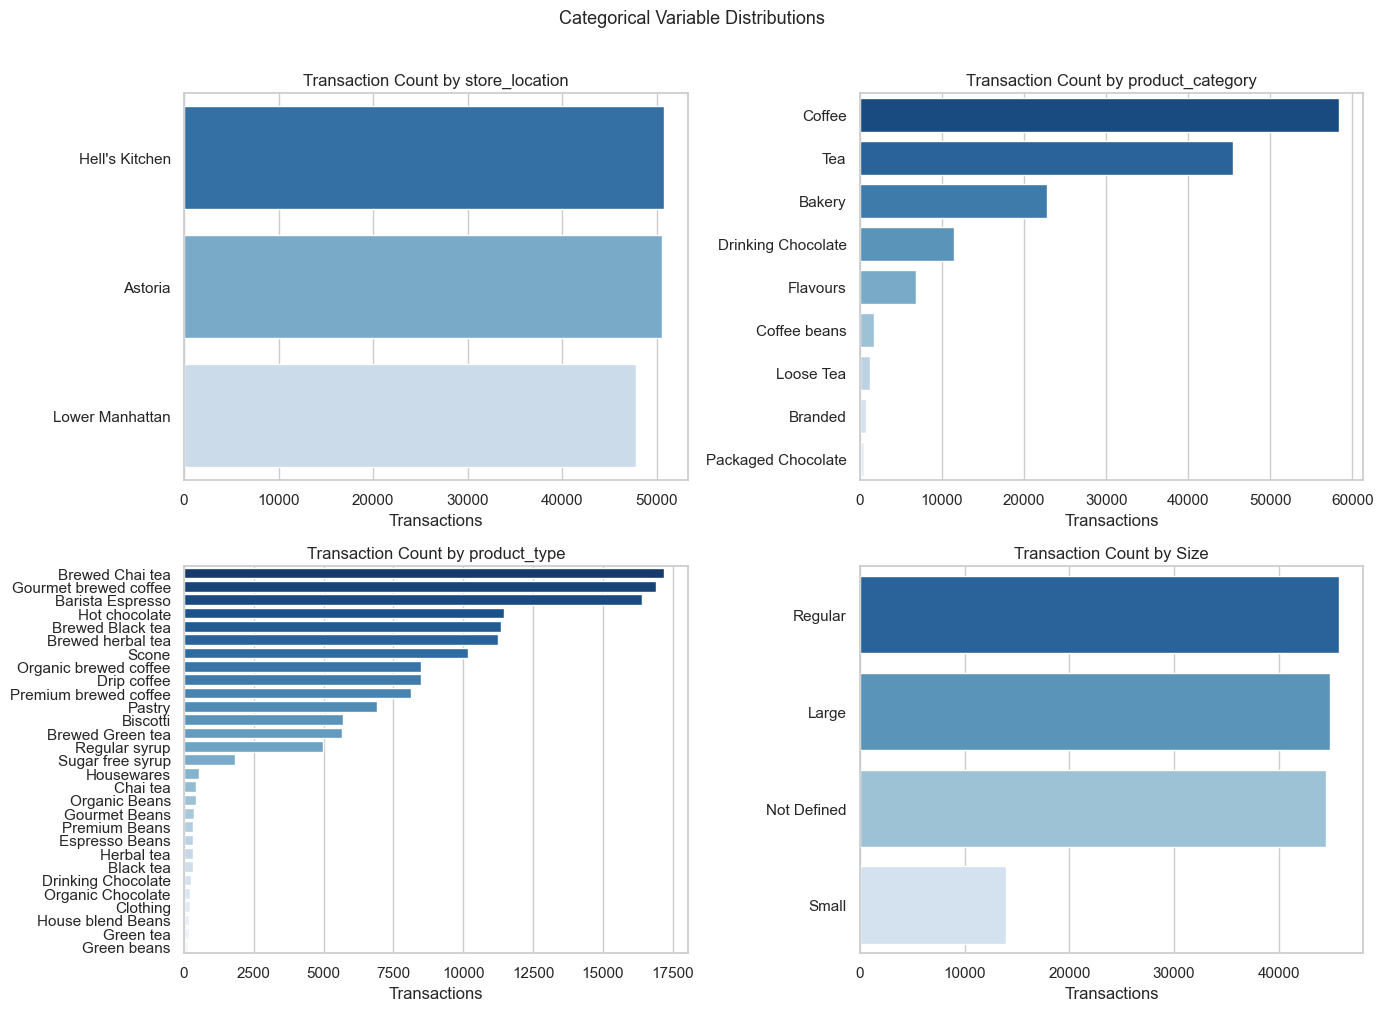

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, 'count']
    sns.barplot(data=counts, x='count', y=col, ax=axes[i],
                hue=col, palette='Blues_r', legend=False)
    axes[i].set_title(f'Transaction Count by {col}')
    axes[i].set_xlabel('Transactions')
    axes[i].set_ylabel('')

plt.suptitle('Categorical Variable Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Coffee dominates with 58,416 transactions (39.2% of all sales), followed by Tea at 45,449 (30.5%). Together they account for nearly 70% of all transactions, confirming this is a beverage-first business. All three store locations are remarkably balanced (~50,000 transactions each), which means store-level comparisons in later questions will be fair and meaningful. Notably, ~30% of transactions (44,518) have "Not Defined" as their size, likely non-sized items like packaged goods or bakery items. This is a data quality flag worth noting but not a reason to remove rows.

### 2.9 EDA Summary: Key Observations

Based on the exploratory analysis above, here are the five most important findings:

1. **The mean transaction value of $4.69 is misleading**: With a skewness of 41.75,
the median of $3.75 is the more honest number. The mean is being pulled upward by a
small segment of premium purchases like coffee beans (avg $21) and branded merchandise
(avg $18), which behave like a completely different business sitting inside the same dataset.

2. **All three stores look identical on the surface, but they are not**: Transaction
volumes are nearly equal (Astoria 50,599, Hell's Kitchen 50,735, Lower Manhattan 47,782),
which makes it tempting to treat them as one business. The EDA hints that product mix
differences across stores tell a more interesting story that volume alone cannot reveal.

3. **Flavours is the most deceptive category in the dataset**: With 6,790 transactions
it ranks 5th in volume, yet generates only $8,409 in revenue at $0.80 per unit. It has more
transactions than Coffee beans, Loose Tea, Branded, and Packaged Chocolate combined,
but contributes less than 1.2% of total revenue.

4. **Revenue collapsed in February then grew 58% over the next three months**: The
chain dropped 6.8% from January to February before rebounding 29.8% in March and
continuing upward. Whether this is seasonal recovery or genuine business growth is a
question the trend analysis will investigate.

5. **Unit price is the strongest predictor of Total_Bill (r = 0.69)**: What a customer
orders matters far more than how many items they buy. Transaction quantity averages just
1.44 units per visit, meaning the pricing strategy behind individual products is the lever
with the most impact on revenue.

# Phase 3: Business Questions
## Q1 Descriptive Statistics
**Question:** The average transaction at this coffee chain is $4.69, but is that number
actually meaningful? With a Total_Bill skewness of 41.75 and a median of only $3.75,
what does the typical customer actually spend, and are there hidden product segments
distorting the numbers across all three stores?

We summarize the three core numeric business metrics: Total_Bill, transaction_qty, and unit_price, reporting measures of central tendency, spread, and shape.

In [16]:
from scipy.stats import mode

metrics = ['Total_Bill', 'transaction_qty', 'unit_price']

summary = []
for col in metrics:
    summary.append({
        'Metric': col,
        'Mean': round(df[col].mean(), 2),
        'Median': round(df[col].median(), 2),
        'Mode': round(df[col].mode()[0], 2),
        'Std Dev': round(df[col].std(), 2),
        'Variance': round(df[col].var(), 2),
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
        'IQR': round(df[col].quantile(0.75) - df[col].quantile(0.25), 2),
        'Skewness': round(df[col].skew(), 3)
    })

summary_df = pd.DataFrame(summary).set_index('Metric')
print("=== DESCRIPTIVE STATISTICS SUMMARY ===")
summary_df

=== DESCRIPTIVE STATISTICS SUMMARY ===


,Mean,Median,Mode,Std Dev,Variance,Min,Max,IQR,Skewness
Metric,,,,,,,,,
Total_Bill,4.69,3.75,3.0,4.23,17.87,0.8,360.0,3.00,41.746
transaction_qty,1.44,1.00,1.0,0.54,0.29,1.0,8.0,1.00,0.800
unit_price,3.38,3.00,3.0,2.66,7.07,0.8,45.0,1.25,8.455


### Q1 Visualization 1: Distribution of Total_Bill (Histogram + KDE)

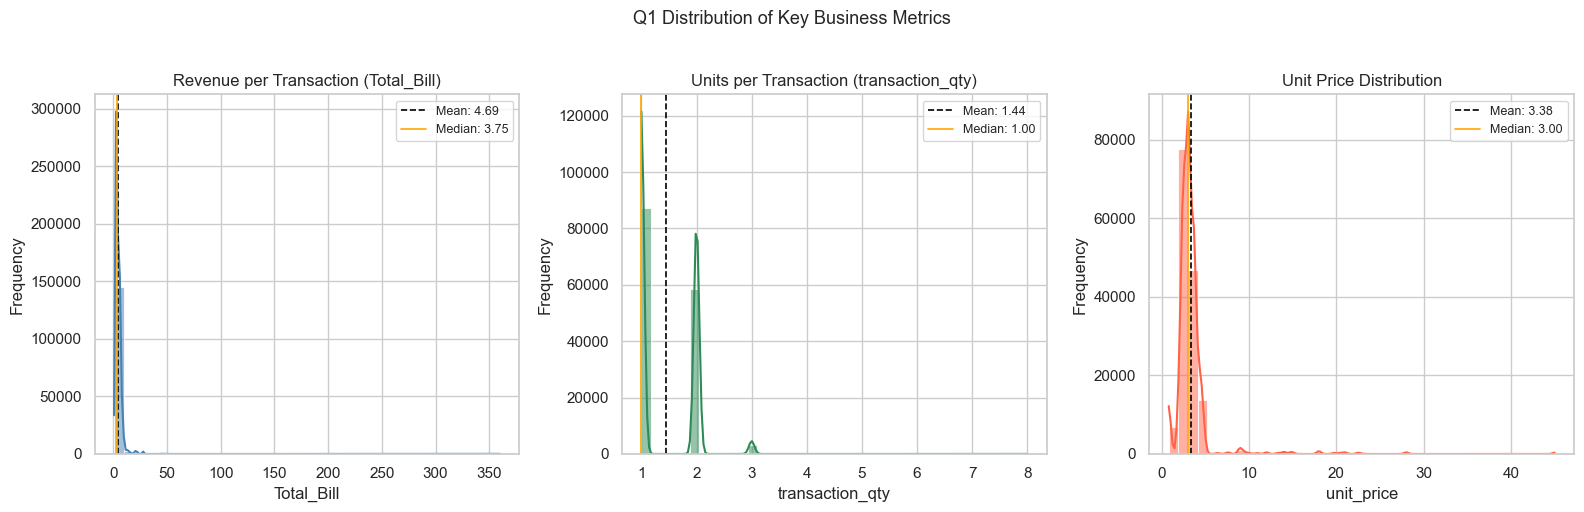

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['steelblue', 'seagreen', 'tomato']
titles = ['Revenue per Transaction (Total_Bill)',
          'Units per Transaction (transaction_qty)',
          'Unit Price Distribution']

for i, (col, color, title) in enumerate(zip(metrics, colors, titles)):
    sns.histplot(df[col], kde=True, ax=axes[i], color=color, bins=40)
    axes[i].axvline(df[col].mean(), color='black', linestyle='--',
                    linewidth=1.2, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',
                    linewidth=1.2, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(title)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Q1 Distribution of Key Business Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Takeaway:** The $4.69 mean is technically correct but practically misleading. The median
of $3.75 tells the real story, the typical customer spends under $4 per visit and buys
exactly 1 item. The gap between mean and median exists because a small number of premium
product purchases (coffee beans at $21 avg, branded merchandise at $18 avg) are pulling
the chain-wide average upward. These are not outlier errors, they represent a genuinely
different type of purchase hidden inside what looks like a uniform dataset.

### Q1 Visualization 2: Transaction Quantity Distribution

How many items does the typical customer buy in a single visit? The histogram above shows Total_Bill is right-skewed, but it does not tell us whether that skew comes from customers buying many items or from a small number of high-priced products. This chart isolates quantity to answer that directly.

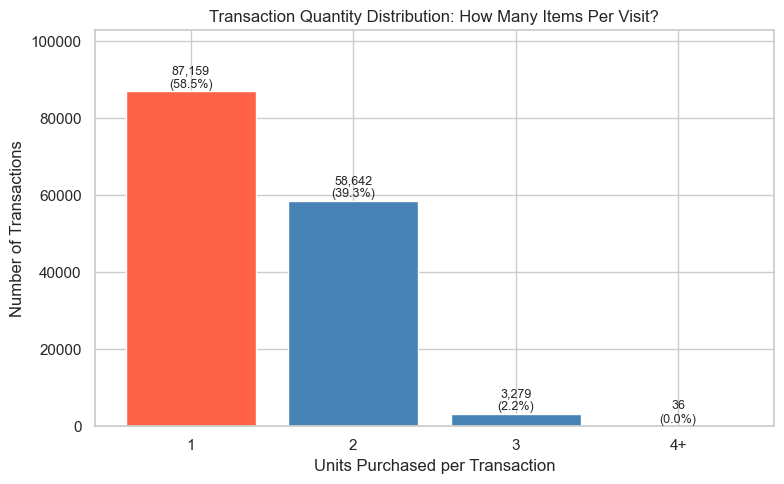

In [18]:
# Transaction quantity distribution
qty_counts = df['transaction_qty'].value_counts().sort_index().reset_index()
qty_counts.columns = ['Quantity', 'Transactions']
qty_counts['Percentage'] = (qty_counts['Transactions'] / len(df) * 100).round(1)

# Collapse anything above 3 into a 4+ bucket for readability
qty_display = qty_counts[qty_counts['Quantity'] <= 3].copy()
bucket_4plus = pd.DataFrame({
    'Quantity': ['4+'],
    'Transactions': [qty_counts[qty_counts['Quantity'] > 3]['Transactions'].sum()],
    'Percentage': [qty_counts[qty_counts['Quantity'] > 3]['Percentage'].sum().round(1)]
})
qty_display['Quantity'] = qty_display['Quantity'].astype(str)
qty_display = pd.concat([qty_display, bucket_4plus], ignore_index=True)

bar_colors = ['tomato' if q == '1' else 'steelblue' for q in qty_display['Quantity']]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(qty_display['Quantity'], qty_display['Transactions'],
              color=bar_colors, edgecolor='white')

for i, row in qty_display.iterrows():
    ax.text(i, row['Transactions'] + 800,
            f"{row['Transactions']:,}\n({row['Percentage']}%)",
            ha='center', fontsize=9)

ax.set_title('Transaction Quantity Distribution: How Many Items Per Visit?')
ax.set_xlabel('Units Purchased per Transaction')
ax.set_ylabel('Number of Transactions')
ax.set_ylim(0, qty_display['Transactions'].max() * 1.18)
plt.tight_layout()
plt.show()

**Interpretation:** This is a single-item purchase business. 58.4% of all transactions are for exactly 1 unit, and another 39.3% are for 2 units. Together they account for 97.7% of all visits. Transactions above 3 units total just 36 across the entire dataset, which are almost certainly bulk or catering orders rather than typical customer behavior. This matters for Q1's central question: the skewness in Total_Bill is not coming from customers buying many items. It is coming from a small number of high-priced products like coffee beans and branded merchandise pulling the mean upward. The typical customer walks in, buys one thing, and leaves.

### Q1 Visualization 3: Average Transaction Value by Product Category

The chain-wide mean of $4.69 treats every product category as if they behave the same way. They do not. Some categories consistently produce higher-value transactions than others, and those premium categories are quietly pulling the mean upward. This chart breaks the average transaction value down by product category to show which segments are distorting the chain-wide number.

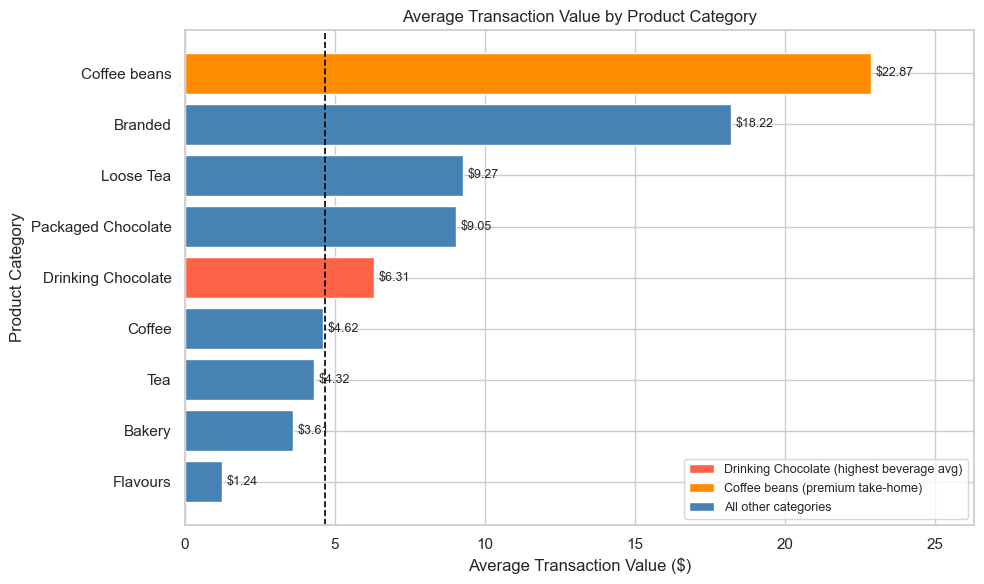

In [19]:
# Average transaction value by product category
cat_avg = df.groupby('product_category')['Total_Bill'].mean().round(2).sort_values(ascending=True)

# Color logic: highlight Drinking Chocolate and Coffee beans as premium tiers
highlight_colors = []
for cat in cat_avg.index:
    if cat == 'Drinking Chocolate':
        highlight_colors.append('tomato')
    elif cat == 'Coffee beans':
        highlight_colors.append('darkorange')
    else:
        highlight_colors.append('steelblue')

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(cat_avg.index, cat_avg.values,
               color=highlight_colors, edgecolor='white')

for i, (val, cat) in enumerate(zip(cat_avg.values, cat_avg.index)):
    ax.text(val + 0.15, i, f'${val:.2f}', va='center', fontsize=9)

# Chain-wide mean reference line
chain_mean = df['Total_Bill'].mean()
ax.axvline(chain_mean, color='black', linestyle='--', linewidth=1.2,
           label=f'Chain-wide mean: ${chain_mean:.2f}')

ax.set_title('Average Transaction Value by Product Category')
ax.set_xlabel('Average Transaction Value ($)')
ax.set_ylabel('Product Category')
ax.set_xlim(0, cat_avg.max() * 1.15)
ax.legend(fontsize=9)

# Manual legend for highlights
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato', label='Drinking Chocolate (highest beverage avg)'),
    Patch(facecolor='darkorange', label='Coffee beans (premium take-home)'),
    Patch(facecolor='steelblue', label='All other categories')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

**Interpretation:** Drinking Chocolate has the highest average transaction value of any beverage category at $6.31, which is 37% above Coffee at $4.62 and well above Tea at $4.32 and Bakery at $3.61. Coffee beans sit in a separate tier entirely at over $20 per transaction, reflecting that customers buying whole beans are making a deliberate premium purchase rather than a quick drink stop. These two categories, Drinking Chocolate and Coffee beans, are the hidden segments pulling the chain-wide mean of $4.69 above the median of $3.75. The practical implication is direct: if the business wants to raise average transaction value, the lever is not getting customers to buy more items (the previous chart showed 97.7% of visits are 1 to 2 units). The lever is steering customers toward higher-priced categories, and Drinking Chocolate is the most underutilized opportunity in that tier.

### Q1 Visualization 4: Revenue by Size

The previous chart showed that product category is a major driver of transaction value. Size is the other lever. A customer ordering a Large drink instead of a Small is making a choice that directly affects the bill, yet size has not been examined anywhere in the analysis so far. Nearly 30% of transactions carry a "Not Defined" size label, which raises a natural question: among the transactions where size is actually recorded, how much does it move the needle?

=== REVENUE BY SIZE ===
         Avg_Bill  Total_Revenue  Transactions
Size                                          
Small        3.33        46403.0         13924
Regular      4.36       199761.0         45789
Large        5.30       237958.0         44885


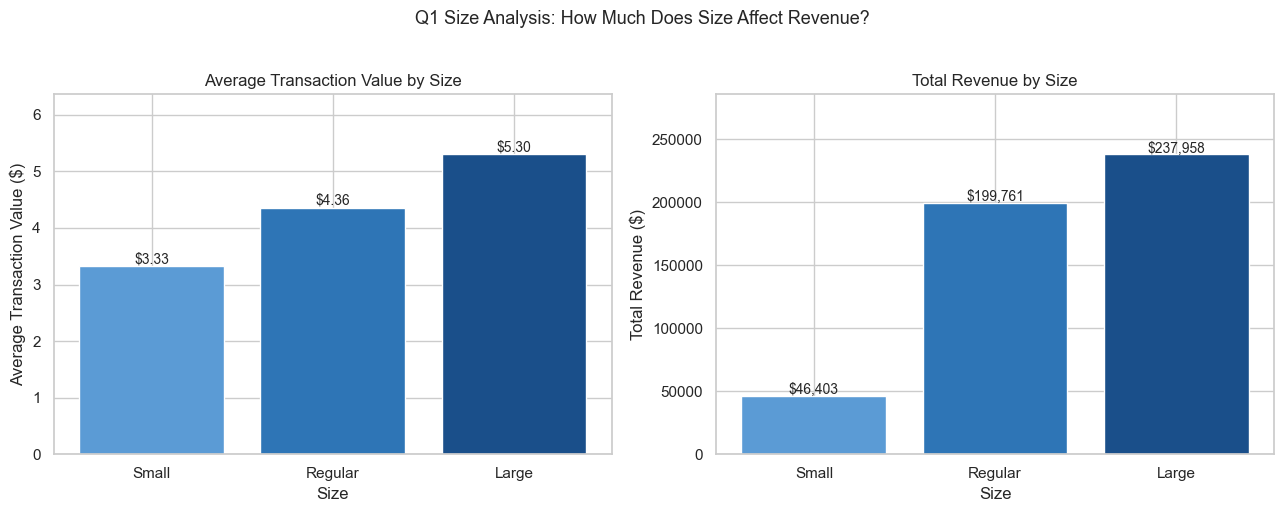

In [20]:
# Filter to sized transactions only (exclude Not Defined)
sized = df[df['Size'] != 'Not Defined'].copy()

# Average bill and total revenue by size
size_order = ['Small', 'Regular', 'Large']
size_stats = sized.groupby('Size')['Total_Bill'].agg(
    Avg_Bill='mean',
    Total_Revenue='sum',
    Transactions='count'
).reindex(size_order).round(2)

size_stats['Avg_Bill'] = size_stats['Avg_Bill'].round(2)
size_stats['Total_Revenue'] = size_stats['Total_Revenue'].round(0)

print("=== REVENUE BY SIZE ===")
print(size_stats)

colors_avg = ['#5b9bd5', '#2e75b6', '#1a4f8a']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: average bill by size
bars0 = axes[0].bar(size_stats.index, size_stats['Avg_Bill'],
                    color=colors_avg, edgecolor='white')
for i, val in enumerate(size_stats['Avg_Bill']):
    axes[0].text(i, val + 0.05, f'${val:.2f}', ha='center', fontsize=10)

axes[0].set_title('Average Transaction Value by Size')
axes[0].set_xlabel('Size')
axes[0].set_ylabel('Average Transaction Value ($)')
axes[0].set_ylim(0, size_stats['Avg_Bill'].max() * 1.2)

# Right: total revenue by size
bars1 = axes[1].bar(size_stats.index, size_stats['Total_Revenue'],
                    color=colors_avg, edgecolor='white')
for i, val in enumerate(size_stats['Total_Revenue']):
    axes[1].text(i, val + 1500, f'${val:,.0f}', ha='center', fontsize=10)

axes[1].set_title('Total Revenue by Size')
axes[1].set_xlabel('Size')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_ylim(0, size_stats['Total_Revenue'].max() * 1.2)

plt.suptitle('Q1 Size Analysis: How Much Does Size Affect Revenue?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Size has a direct and measurable impact on revenue per transaction. A Large drink averages $5.30 per visit compared to $3.33 for a Small, a difference of 59%. Regular sits in the middle at $4.36. In total revenue terms, Large and Regular are the two dominant tiers, generating $237,958 and $199,761 respectively across the six-month period, while Small contributes just $46,403. The 44,518 transactions labeled "Not Defined" are excluded here because they represent non-sized products such as coffee beans, packaged goods, and bakery items rather than missing data. Among drinks where size is actually recorded, the pattern is clear and consistent: every step up in size adds roughly $1 to the average bill. Combined with the previous chart showing that Drinking Chocolate already carries a premium average ticket, a customer ordering a Large Drinking Chocolate represents the highest-value everyday transaction this chain can generate without selling a specialty product.

### Q1 Per-Store Descriptive Comparison

In [21]:
store_stats = df.groupby('store_location')['Total_Bill'].agg(
    Mean='mean',
    Median='median',
    Std='std',
    Total_Revenue='sum',
    Transactions='count'
).round(2)

store_stats['Avg_per_transaction'] = store_stats['Total_Revenue'] / store_stats['Transactions']
store_stats['Avg_per_transaction'] = store_stats['Avg_per_transaction'].round(2)

print("=== PER-STORE REVENUE STATISTICS ===")
store_stats

=== PER-STORE REVENUE STATISTICS ===


,Mean,Median,Std,Total_Revenue,Transactions,Avg_per_transaction
store_location,,,,,,
Astoria,4.59,3.75,2.88,232243.91,50599,4.59
Hell's Kitchen,4.66,3.75,5.84,236511.17,50735,4.66
Lower Manhattan,4.81,3.75,3.28,230057.25,47782,4.81


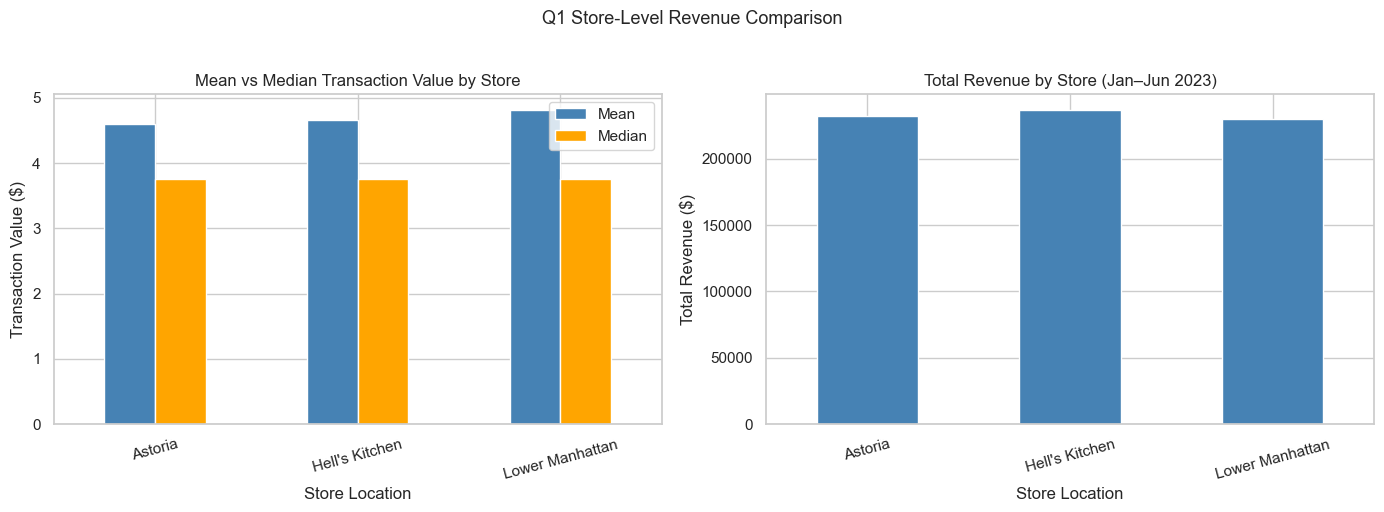

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean vs Median by store
store_stats[['Mean', 'Median']].plot(kind='bar', ax=axes[0],
                                      color=['steelblue', 'orange'],
                                      edgecolor='white')
axes[0].set_title('Mean vs Median Transaction Value by Store')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Transaction Value ($)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(['Mean', 'Median'])

# Total revenue by store
store_stats['Total_Revenue'].plot(kind='bar', ax=axes[1],
                                   color='steelblue', edgecolor='white')
axes[1].set_title('Total Revenue by Store (Jan–Jun 2023)')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.suptitle('Q1 Store-Level Revenue Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Business Interpretation:** On the surface all three stores look identical, same median
($3.75), similar total revenues, and similar transaction counts. But the standard deviation
tells a different story: Hell's Kitchen has a std of 5.84 versus Astoria's 2.88, meaning
Hell's Kitchen has far more variability in transaction values. This is the first hint that
Hell's Kitchen is not just selling more, it is selling differently, with a wider spread of
purchase types that the other stores do not have. This difference in variability will be explored further in Q3, where we break down product performance by store to understand what is actually driving it.

## Q2 Trend Analysis
**Question:** Revenue fell across all three stores in February before rebounding 30% in
March and accelerating another 58% through May. Is this coffee chain actually growing,
or is it simply recovering from a seasonal slump, and will the momentum hold?

We analyze revenue and transaction volume over time at three levels: monthly chain-wide,
monthly per store, and by day of week, to determine whether the February dip and subsequent
growth are seasonal patterns or signs of genuine business momentum.

In [23]:
# Monthly revenue and transaction volume chain-wide
monthly = df.groupby('Month').agg(
    Total_Revenue=('Total_Bill', 'sum'),
    Transactions=('transaction_id', 'count')
).reset_index()

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun'}
monthly['Month Name'] = monthly['Month'].map(month_names)

# Month over month growth rate
monthly['Revenue_Growth_%'] = monthly['Total_Revenue'].pct_change() * 100

print("=== MONTHLY REVENUE SUMMARY ===")
print(monthly[['Month Name', 'Total_Revenue', 'Transactions', 'Revenue_Growth_%']].round(2).to_string(index=False))

=== MONTHLY REVENUE SUMMARY ===
Month Name  Total_Revenue  Transactions  Revenue_Growth_%
       Jan       81677.74         17314               NaN
       Feb       76145.19         16359             -6.77
       Mar       98834.68         21229             29.80
       Apr      118941.08         25335             20.34
       May      156727.76         33527             31.77
       Jun      166485.88         35352              6.23


### Q2 Visualization 1: Monthly Revenue Trend with Growth Rate

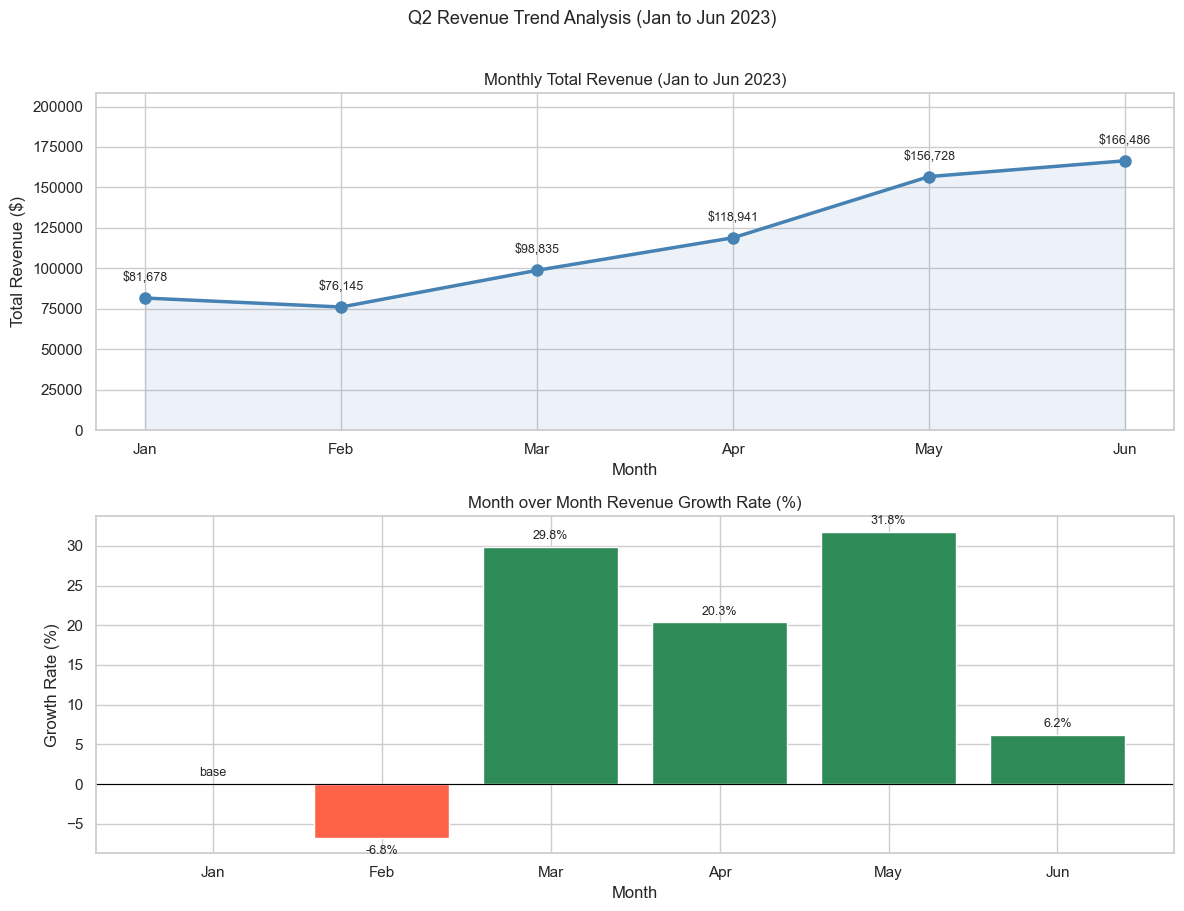

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Top: Total revenue line chart
axes[0].plot(monthly['Month Name'], monthly['Total_Revenue'],
             marker='o', color='steelblue', linewidth=2.5, markersize=8)
axes[0].fill_between(monthly['Month Name'], monthly['Total_Revenue'],
                     alpha=0.1, color='steelblue')
for i, row in monthly.iterrows():
    axes[0].annotate(f"${row['Total_Revenue']:,.0f}",
                     (row['Month Name'], row['Total_Revenue']),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=9)
axes[0].set_title('Monthly Total Revenue (Jan to Jun 2023)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_ylim(0, monthly['Total_Revenue'].max() * 1.25)

# Bottom: Month over month growth rate bar chart
colors_growth = ['tomato' if x < 0 else 'seagreen'
                 for x in monthly['Revenue_Growth_%'].fillna(0)]
axes[1].bar(monthly['Month Name'], monthly['Revenue_Growth_%'].fillna(0),
            color=colors_growth, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
for i, (month, val) in enumerate(zip(monthly['Month Name'],
                                      monthly['Revenue_Growth_%'].fillna(0))):
    axes[1].text(i, val + (1 if val >= 0 else -2),
                 f"{val:.1f}%" if i > 0 else "base",
                 ha='center', fontsize=9)
axes[1].set_title('Month over Month Revenue Growth Rate (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Growth Rate (%)')

plt.suptitle('Q2 Revenue Trend Analysis (Jan to Jun 2023)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Revenue did not just dip in February and bounce back. It accelerated. The chain earned $81,678 in January, fell to $76,145 in February (down 6.77%), then climbed to $98,835 in March, $118,941 in April, and $156,728 in May before reaching a six-month high of $166,486 in June. The growth rate itself tells the story: three consecutive months above 20%, with May posting 31.77%. This does not look like a recovery from a seasonal slump. It looks like demand building momentum as the year progresses, possibly driven by warmer weather driving more foot traffic and longer café visits. Whether that momentum holds into the second half of 2023 is the key unanswered question.

### Q2 Visualization 2: Monthly Revenue by Store (Did all stores dip in February?)

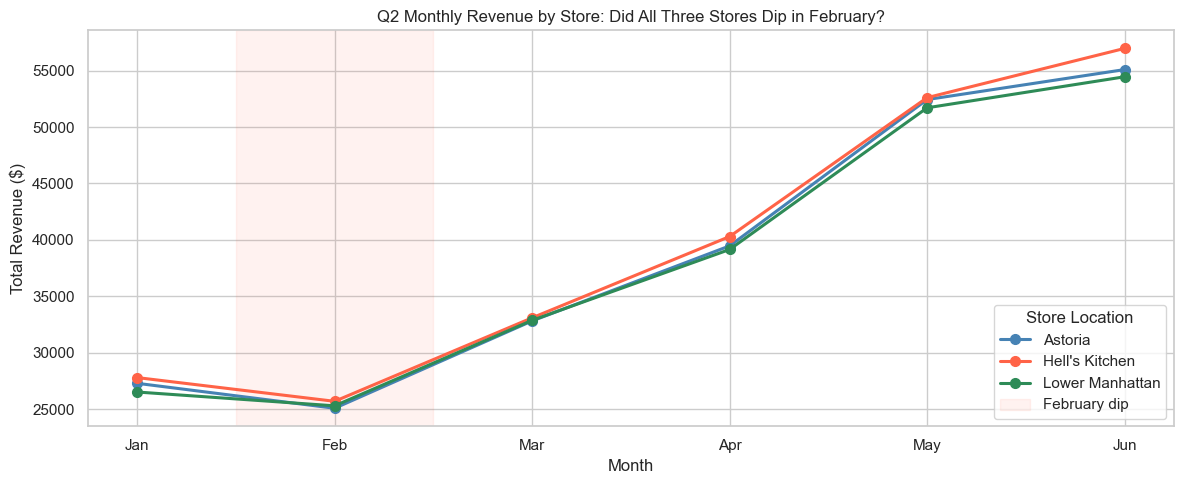

In [25]:
# Monthly revenue broken down by store
monthly_store = df.groupby(['Month', 'store_location'])['Total_Bill'].sum().reset_index()
monthly_store['Month Name'] = monthly_store['Month'].map(month_names)

store_colors = {
    'Astoria': 'steelblue',
    "Hell's Kitchen": 'tomato',
    'Lower Manhattan': 'seagreen'
}

plt.figure(figsize=(12, 5))
for store, group in monthly_store.groupby('store_location'):
    plt.plot(group['Month Name'], group['Total_Bill'],
             marker='o', linewidth=2.2, markersize=7,
             label=store, color=store_colors[store])

# Highlight February dip
plt.axvspan(0.5, 1.5, alpha=0.08, color='tomato', label='February dip')

plt.title('Q2 Monthly Revenue by Store: Did All Three Stores Dip in February?')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Store Location')
plt.tight_layout()
plt.show()

**Interpretation:** All three stores dipped in February, and the magnitude was proportional. Astoria fell the most at 8.09%, followed by Hell's Kitchen at 7.55%, and Lower Manhattan at only 4.61%. The fact that Lower Manhattan held up slightly better during the winter month is consistent with what the later hourly drill-down will show: it serves an early-morning financial district commuter crowd whose behavior is less affected by cold weather than a neighborhood or entertainment-area café. What stands out beyond the dip is how all three stores move together throughout the six months. Their revenue lines never cross or diverge sharply. Whatever is driving growth chain-wide, whether seasonality, foot traffic, or a growing customer base, it is lifting all three locations at roughly the same pace

### Q2 Visualization 3: Revenue by Day of Week

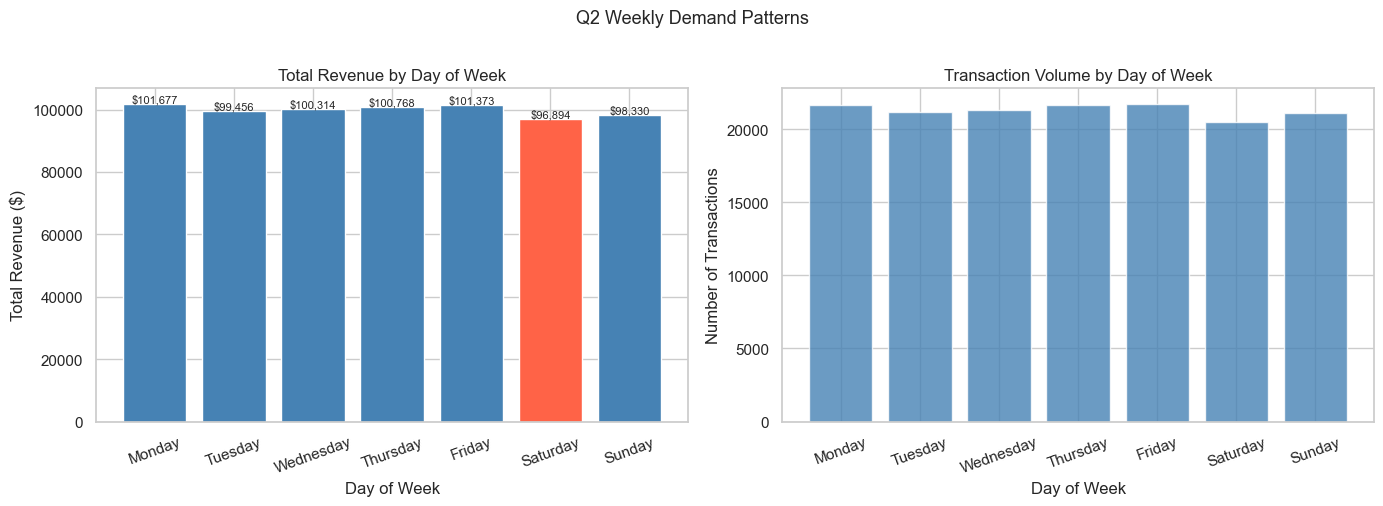

In [26]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = df.groupby('Day Name').agg(
    Total_Revenue=('Total_Bill', 'sum'),
    Transactions=('transaction_id', 'count'),
    Avg_Bill=('Total_Bill', 'mean')
).reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue by day
bar_colors = ['tomato' if r == dow['Total_Revenue'].min()
              else 'steelblue' for r in dow['Total_Revenue']]
axes[0].bar(dow['Day Name'], dow['Total_Revenue'],
            color=bar_colors, edgecolor='white')
axes[0].set_title('Total Revenue by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].set_xticks(range(len(dow['Day Name'])))
axes[0].set_xticklabels(dow['Day Name'], rotation=20)
for i, val in enumerate(dow['Total_Revenue']):
    axes[0].text(i, val + 500, f'${val:,.0f}', ha='center', fontsize=8)

# Transaction count by day
axes[1].bar(dow['Day Name'], dow['Transactions'],
            color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Transaction Volume by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xticks(range(len(dow['Day Name'])))
axes[1].set_xticklabels(dow['Day Name'], rotation=20)

plt.suptitle('Q2 Weekly Demand Patterns', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** The weekly revenue pattern is almost flat across all seven days, which is unusual for a café and worth examining. Revenue ranges from a low of $96,894 on Saturday to a high of $101,677 on Monday, a spread of less than 5%. Transaction counts follow the same pattern, with Saturday posting the fewest visits at 20,510 compared to Friday's 21,701. Saturday being the weakest day despite being a weekend is the counterintuitive finding here. It strongly suggests that this chain's customer base is driven by weekday routine, commuters, office workers, and people on a daily schedule, rather than by leisure weekend visitors. A café in a tourist area or a residential neighborhood would expect Saturday to be among its strongest days. Here it is the weakest, which has direct implications for staffing and promotional strategy.

## Q3 Cross-Tabulation Analysis
**Question:** Hell's Kitchen generates 82% more coffee bean revenue than Astoria despite
having nearly the same number of total transactions. Are the three stores actually selling
to the same type of customer, or are their product preferences fundamentally different?

We examine the interaction between two categorical dimensions: product_category and
store_location, using pd.crosstab() to aggregate total revenue. A heatmap reveals whether
product preferences differ meaningfully across stores or whether all three locations share
the same sales mix.

In [27]:
# Cross-tabulation: product_category x store_location by total revenue
crosstab = pd.crosstab(
    index=df['product_category'],
    columns=df['store_location'],
    values=df['Total_Bill'],
    aggfunc='sum'
).round(2)

# Sort by total revenue descending
crosstab['Total'] = crosstab.sum(axis=1)
crosstab = crosstab.sort_values('Total', ascending=False).drop(columns='Total')

print("=== REVENUE CROSSTAB: Product Category x Store Location ===")
print(crosstab)

=== REVENUE CROSSTAB: Product Category x Store Location ===
store_location       Astoria  Hell's Kitchen  Lower Manhattan
product_category                                             
Coffee              89744.30        91222.65         88985.50
Tea                 67839.90        64701.30         63864.75
Bakery              26599.75        27386.95         28328.94
Drinking Chocolate  26335.25        23586.25         22494.50
Coffee beans        10219.20        18635.10         11230.95
Branded              5457.00         1942.00          6208.00
Loose Tea            3194.00         4461.35          3558.25
Flavours             1764.80         2876.80          3767.20
Packaged Chocolate   1089.71         1698.77          1619.16


### Q3 Visualization 1: Revenue Heatmap (Absolute and Percentage Share)

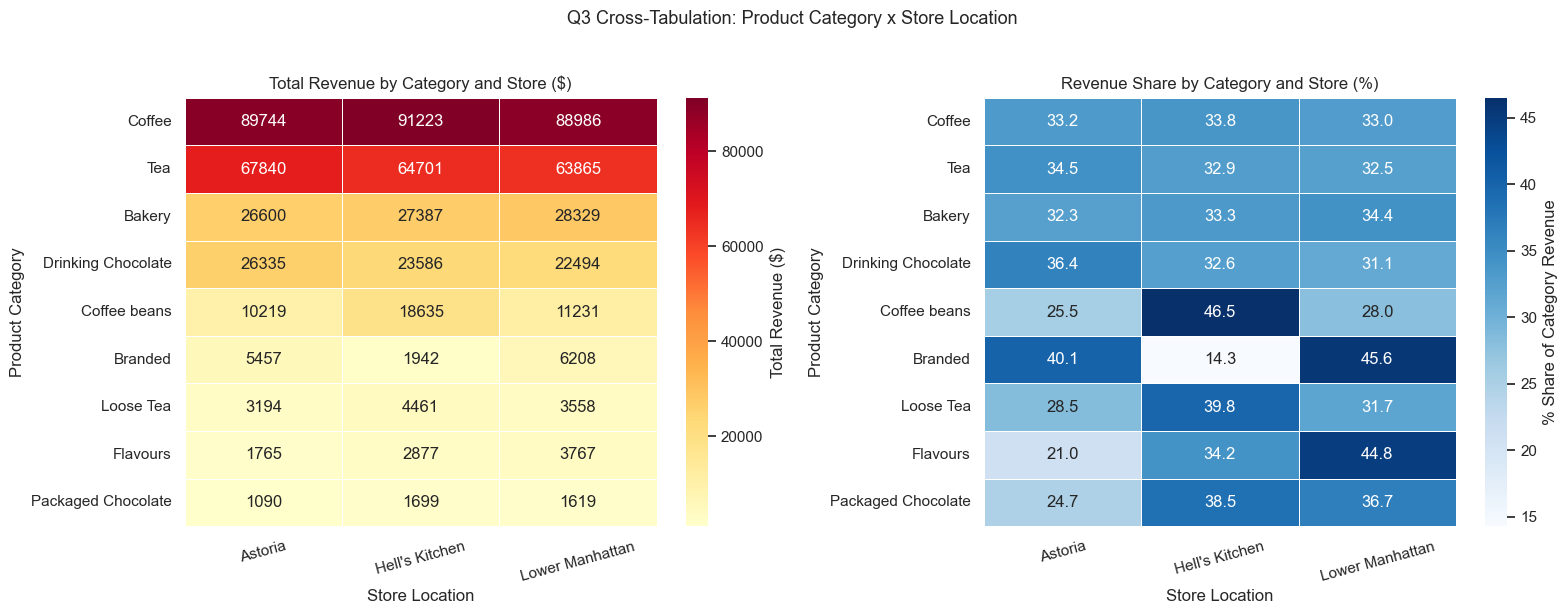

In [28]:
# Row-normalized version: each cell = % of that category's revenue at each q3 vis
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0).round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute revenue heatmap
sns.heatmap(crosstab, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Total Revenue ($)'})
axes[0].set_title('Total Revenue by Category and Store ($)')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Product Category')
axes[0].tick_params(axis='x', rotation=15)

# Right: percentage share heatmap
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': '% Share of Category Revenue'})
axes[1].set_title('Revenue Share by Category and Store (%)')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('Product Category')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Q3 Cross-Tabulation: Product Category x Store Location',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The absolute revenue heatmap confirms that Coffee is the dominant category at all three stores, generating roughly $89,000 to $91,000 each. At that scale, the differences look small. Switching to the percentage share heatmap reveals what the raw numbers hide. Coffee beans make up 7.9% of Hell's Kitchen's total revenue compared to 4.4% at Astoria and 4.9% at Lower Manhattan. Branded merchandise shows the opposite pattern, contributing 2.7% at Lower Manhattan and 2.4% at Astoria, but only 0.8% at Hell's Kitchen. These are not rounding differences. They reflect genuinely different customer behavior across locations that share the exact same menu and are separated by just a few subway stops. The heatmap's value here is precisely that it makes both the dominant similarity and the outlier differences visible at the same time.

### Q3 Visualization 2: Top 5 Categories by Store (Grouped Bar Chart)

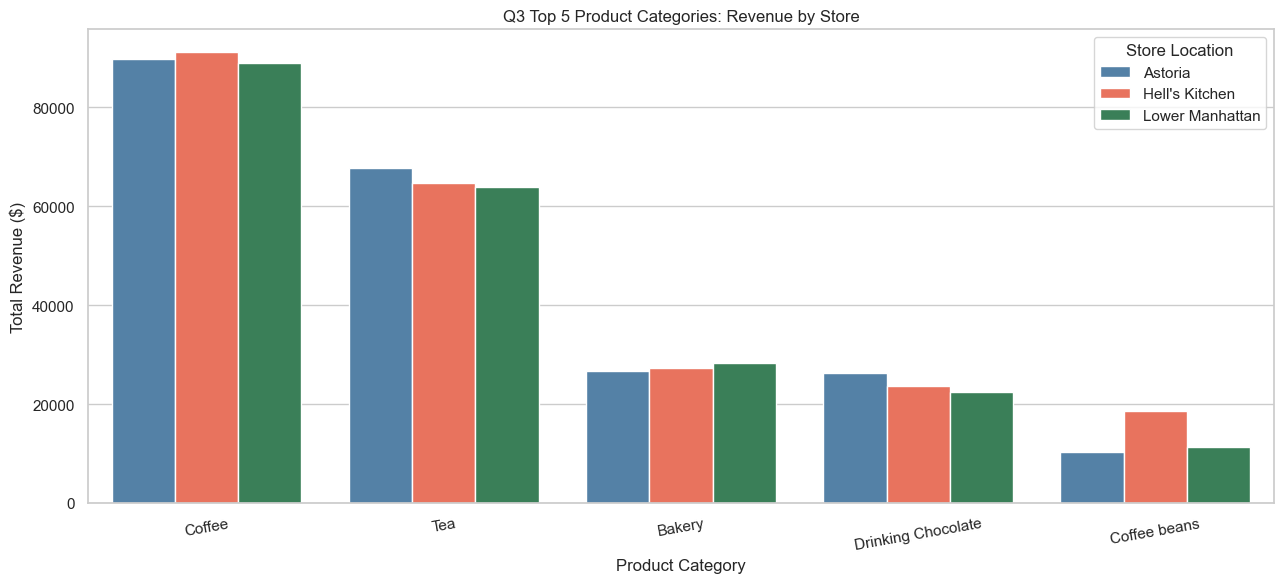

In [29]:
# Focus on top 5 categories by total revenue for readability
top_cats = crosstab.sum(axis=1).nlargest(5).index

crosstab_melted = crosstab.reset_index().melt(
    id_vars='product_category',
    var_name='Store',
    value_name='Revenue'
)
top_melted = crosstab_melted[crosstab_melted['product_category'].isin(top_cats)]

plt.figure(figsize=(13, 6))
sns.barplot(data=top_melted, x='product_category', y='Revenue',
            hue='Store', palette=['steelblue', 'tomato', 'seagreen'])
plt.title('Q3 Top 5 Product Categories: Revenue by Store')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Store Location')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Interpretation:** Across the top five revenue categories, Coffee, Tea, Bakery, Drinking Chocolate, and Coffee beans, four of them look nearly identical across all three stores. The bars for Coffee, Tea, Bakery, and Drinking Chocolate are so close in height that no single store has a meaningful advantage. Coffee beans is the category that breaks the pattern completely. Hell's Kitchen's bar stands visibly taller, generating $18,635 compared to $10,219 at Astoria and $11,231 at Lower Manhattan. This is not a marginal difference. Hell's Kitchen earns 82% more from coffee beans than Astoria despite the two stores handling almost identical total transaction volumes. The grouped bar chart isolates that single divergence from an otherwise uniform product mix and makes it impossible to explain away as noise.

### Q3 Visualization 3: Coffee Beans Revenue by Store (The Key Finding)

=== COFFEE BEANS PERFORMANCE BY STORE ===
                  Revenue  Transactions  Avg_Price  Pct_of_Store_Revenue
store_location                                                          
Astoria          10219.20           502      20.36                  4.40
Hell's Kitchen   18635.10           720      21.51                  7.88
Lower Manhattan  11230.95           531      20.98                  4.88


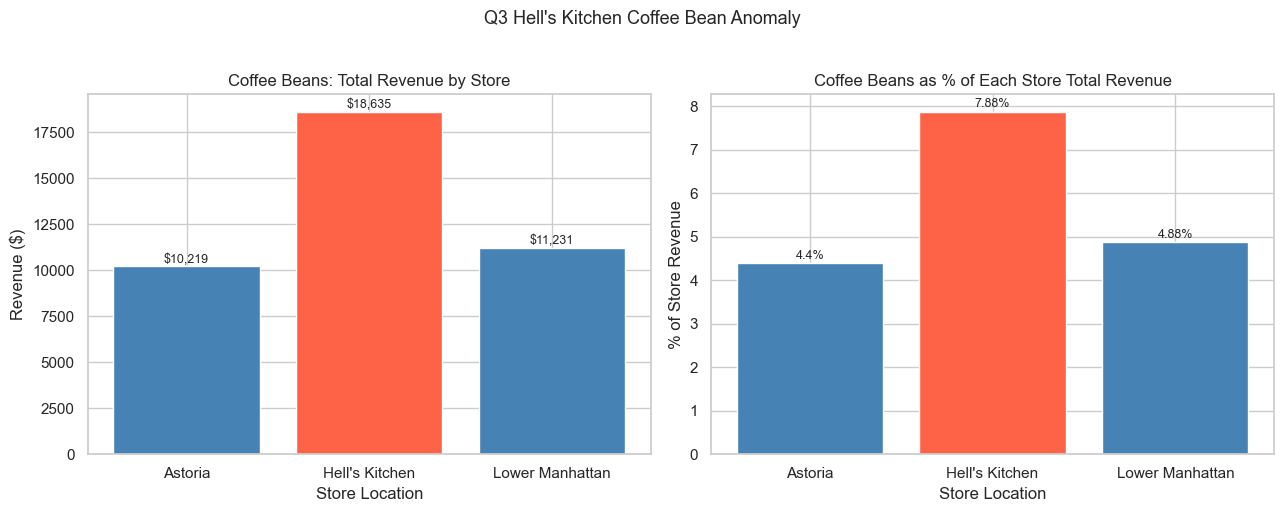

In [30]:
# Isolate coffee beans specifically since it shows the most striking difference
beans = df[df['product_category'] == 'Coffee beans'].groupby('store_location').agg(
    Revenue=('Total_Bill', 'sum'),
    Transactions=('transaction_id', 'count'),
    Avg_Price=('unit_price', 'mean')
).round(2)

# Revenue share of coffee beans within each store
total_per_store = df.groupby('store_location')['Total_Bill'].sum()
beans['Pct_of_Store_Revenue'] = (beans['Revenue'] / total_per_store * 100).round(2)

print("=== COFFEE BEANS PERFORMANCE BY STORE ===")
print(beans)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue bar chart
bar_colors = ['tomato' if s == "Hell's Kitchen" else 'steelblue'
              for s in beans.index]
axes[0].bar(beans.index, beans['Revenue'], color=bar_colors, edgecolor='white')
axes[0].set_title('Coffee Beans: Total Revenue by Store')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Revenue ($)')
for i, val in enumerate(beans['Revenue']):
    axes[0].text(i, val + 200, f'${val:,.0f}', ha='center', fontsize=9)

# Percentage of store revenue
axes[1].bar(beans.index, beans['Pct_of_Store_Revenue'],
            color=bar_colors, edgecolor='white')
axes[1].set_title('Coffee Beans as % of Each Store Total Revenue')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('% of Store Revenue')
for i, val in enumerate(beans['Pct_of_Store_Revenue']):
    axes[1].text(i, val + 0.1, f'{val}%', ha='center', fontsize=9)

plt.suptitle("Q3 Hell's Kitchen Coffee Bean Anomaly", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The coffee bean gap between Hell's Kitchen and the other two stores is both large and meaningful. Hell's Kitchen completed 720 coffee bean transactions versus 502 at Astoria and 531 at Lower Manhattan, and it did so at a slightly higher average price of $21.51 per transaction compared to $20.36 and $20.98. The revenue difference comes primarily from volume, not price. Hell's Kitchen is attracting more customers who come in specifically to buy whole beans, a deliberate purchase that takes more planning than a walk-up drink order. At 7.9% of total store revenue, coffee beans are a strategically significant category for Hell's Kitchen in a way they simply are not for the other two locations. This points to a question worth investigating in Q6: is Hell's Kitchen functioning as something closer to a specialty coffee destination rather than a standard café stop?

### Q3 Visualization 4: Branded Merchandise Revenue by Store (The Opposite Pattern)

=== BRANDED MERCHANDISE PERFORMANCE BY STORE ===
                 Revenue  Transactions  Pct_of_Store_Revenue
store_location                                              
Astoria           5457.0           279                  2.35
Hell's Kitchen    1942.0           119                  0.82
Lower Manhattan   6208.0           349                  2.70


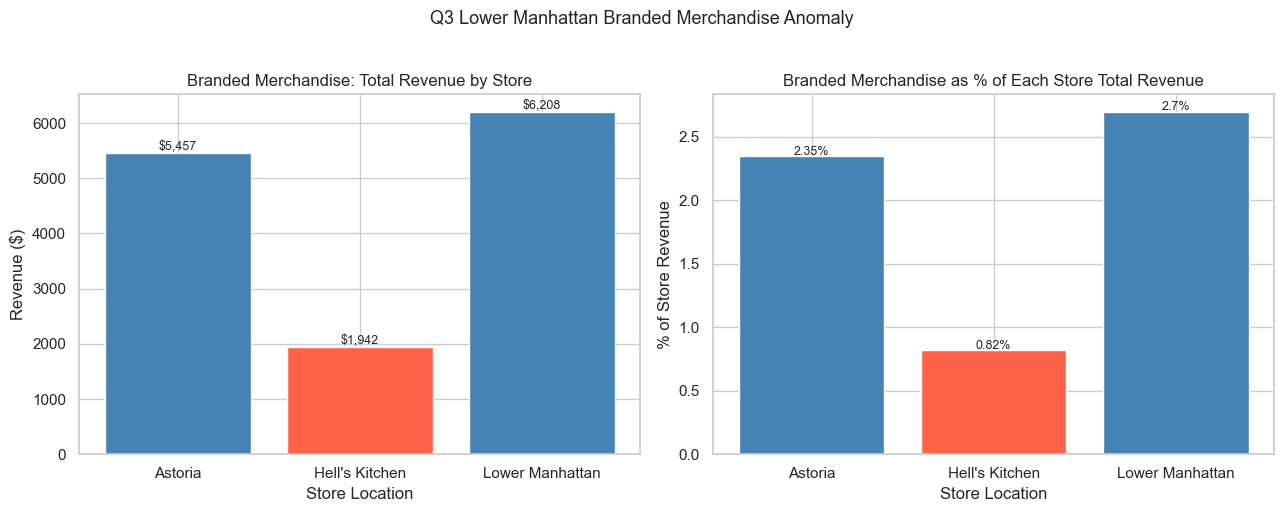

In [31]:
branded = df[df['product_category'] == 'Branded'].groupby('store_location').agg(
    Revenue=('Total_Bill', 'sum'),
    Transactions=('transaction_id', 'count')
).round(2)

branded['Pct_of_Store_Revenue'] = (branded['Revenue'] / total_per_store * 100).round(2)

print("=== BRANDED MERCHANDISE PERFORMANCE BY STORE ===")
print(branded)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_colors_b = ['tomato' if s == "Hell's Kitchen" else 'steelblue'
                for s in branded.index]

axes[0].bar(branded.index, branded['Revenue'],
            color=bar_colors_b, edgecolor='white')
axes[0].set_title('Branded Merchandise: Total Revenue by Store')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Revenue ($)')
for i, val in enumerate(branded['Revenue']):
    axes[0].text(i, val + 50, f'${val:,.0f}', ha='center', fontsize=9)

axes[1].bar(branded.index, branded['Pct_of_Store_Revenue'],
            color=bar_colors_b, edgecolor='white')
axes[1].set_title('Branded Merchandise as % of Each Store Total Revenue')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('% of Store Revenue')
for i, val in enumerate(branded['Pct_of_Store_Revenue']):
    axes[1].text(i, val + 0.01, f'{val}%', ha='center', fontsize=9)

plt.suptitle('Q3 Lower Manhattan Branded Merchandise Anomaly', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Branded merchandise is where Hell's Kitchen's specialty advantage disappears entirely. Lower Manhattan leads with $6,208 in branded revenue across 349 transactions, Astoria sits in the middle at $5,457 across 279 transactions, and Hell's Kitchen trails significantly at only $1,942 across 119 transactions. As a share of store revenue, branded products account for 2.7% at Lower Manhattan and 2.4% at Astoria, but only 0.8% at Hell's Kitchen. The same store that attracts customers willing to spend $21 on specialty beans produces far fewer customers interested in mugs, bags, or branded merchandise, suggesting the Hell's Kitchen customer visits with a specific product purpose in mind rather than browsing for lifestyle purchases.

Taken together, the four visualizations in Q3 tell a consistent story. Coffee dominates revenue at all three stores, and across the top five categories the locations track closely enough to look like a single business. But the percentage share heatmap exposes two divergences that raw totals hide: Hell's Kitchen generates 7.9% of its store revenue from coffee beans compared to 4.4% at Astoria and 4.9% at Lower Manhattan, while Lower Manhattan leads branded merchandise at 2.7% versus Hell's Kitchen's 0.8%. These two patterns point in opposite directions at the same store. Three locations sharing the same menu but attracting customers who shop in fundamentally different ways. That question will be explored further in Q6.

## Q4 Drill-Down Analysis

**Question:** 49% of this coffee chain's daily revenue is generated before 11am in a 4-hour window. When you break down total revenue by store, then by product category, then by hour, where exactly is the money coming from, and what does the afternoon look like in comparison?

We begin the drill-down at the broadest level: revenue by hour and by store. Before examining what is being sold and when, we need to understand when each store is actually open and generating revenue. The three stores do not share the same operating hours, and that difference turns out to be one of the most operationally significant findings in the entire dataset.

### Q4 Visualization 1: Revenue by Hour and Store, Three Stores, Three Different Days

=== REVENUE BY HOUR AND STORE ===
Hour                  6        7        8        9        10       11       12       13       14       15       16       17       18       19      20
store_location                                                                                                                                       
Astoria              0.0  19029.0  22806.0  23184.0  24426.0  15498.0  15681.0  15948.0  15175.0  15652.0  16111.0  15839.0  15951.0  16944.0     0.0
Hell's Kitchen    7531.0  15961.0  31544.0  32874.0  33606.0  17927.0  11343.0  12070.0  12298.0  11311.0  11990.0  12790.0  11863.0  10766.0  2636.0
Lower Manhattan  14369.0  28537.0  28350.0  29112.0  30641.0  12894.0  13168.0  12349.0  13832.0  14770.0  13021.0  11506.0   6472.0    737.0   299.0


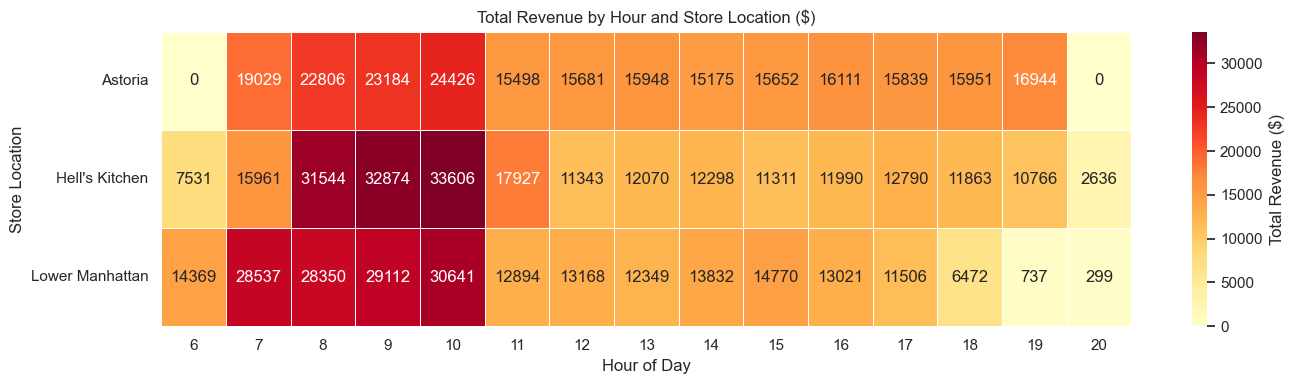

In [32]:
# Revenue by hour and store
hour_store = df.groupby(['Hour', 'store_location'])['Total_Bill'].sum().reset_index()
hour_store_pivot = hour_store.pivot(index='store_location', columns='Hour', values='Total_Bill').fillna(0).round(0)

print("=== REVENUE BY HOUR AND STORE ===")
print(hour_store_pivot.to_string())

fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    hour_store_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Total Revenue ($)'}
)

ax.set_title('Total Revenue by Hour and Store Location ($)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Store Location')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

**Interpretation:** This heatmap immediately reveals something the monthly and weekly trend charts could not: the three stores operate on fundamentally different schedules. Lower Manhattan opens the earliest, generating $14,369 at hour 6 alone, which reflects the early commuter traffic of a financial district location where workers arrive before most of the city is awake. Astoria generates zero revenue at hour 6 and zero again at hour 20, meaning it operates a tighter window aligned with a residential neighborhood that moves on a later schedule. Hell's Kitchen is the only store still generating meaningful revenue at hour 20 with $2,636, consistent with an entertainment district that stays active into the evening. By hour 11, all three stores have generated the bulk of their daily revenue, but the morning ramp-up and evening tail look completely different depending on location. Treating these three stores as a single operation with uniform staffing and inventory schedules would mean overstaffing Astoria in the early morning and understaffing Hell's Kitchen in the evening. The operating hour profile is not a minor detail. It is one of the most actionable findings in the dataset.

### Q4 Visualization 2: Top 10 Products by Revenue, What Is Actually Driving the Numbers?

The heatmap above showed when and where revenue is being generated. The next question is what. The cross-tabulation in Q3 established that Coffee dominates at the category level, but category-level analysis masks which specific products are carrying the most weight. Ethiopia appearing as the single highest-revenue product in the entire chain is a finding that never surfaced anywhere in the notebook until now.

=== TOP 10 PRODUCTS BY REVENUE ===
                  Product  Total_Revenue           Category
                 Ethiopia       42304.10             Coffee
Sustainably Grown Organic       39065.10 Drinking Chocolate
    Jamaican Coffee River       38781.15             Coffee
                Brazilian       37746.50             Coffee
                    Latte       36369.75             Coffee
           Dark chocolate       35785.70 Drinking Chocolate
 Our Old Time Diner Blend       35278.00             Coffee
   Columbian Medium Roast       34528.50             Coffee
               Cappuccino       33639.25             Coffee
     Morning Sunrise Chai       30587.50                Tea


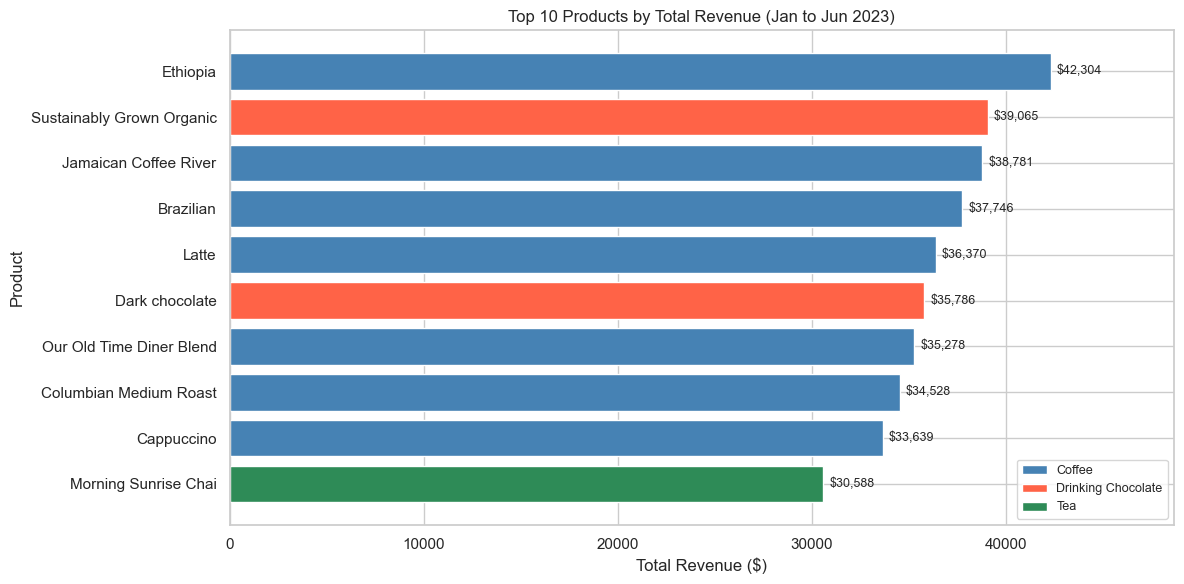

In [33]:
# Top 10 products by total revenue
top_products = df.groupby('product_detail')['Total_Bill'].sum().round(2).sort_values(ascending=False).head(10).reset_index()
top_products.columns = ['Product', 'Total_Revenue']
top_products['Category'] = df.groupby('product_detail')['product_category'].first().reindex(top_products['Product']).values

print("=== TOP 10 PRODUCTS BY REVENUE ===")
print(top_products.to_string(index=False))

# Color by category
category_colors = {
    'Coffee beans': 'darkorange',
    'Coffee': 'steelblue',
    'Tea': 'seagreen',
    'Drinking Chocolate': 'tomato',
    'Bakery': 'mediumpurple',
    'Branded': 'gray',
    'Flavours': 'gold',
    'Loose Tea': 'mediumseagreen',
    'Packaged Chocolate': 'saddlebrown'
}

bar_colors = [category_colors.get(cat, 'steelblue') for cat in top_products['Category']]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top_products['Product'][::-1], top_products['Total_Revenue'][::-1],
               color=bar_colors[::-1], edgecolor='white')

for i, val in enumerate(top_products['Total_Revenue'][::-1]):
    ax.text(val + 300, i, f'${val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 Products by Total Revenue (Jan to Jun 2023)')
ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('Product')
ax.set_xlim(0, top_products['Total_Revenue'].max() * 1.15)

# Legend for category colors
from matplotlib.patches import Patch
present_cats = list(dict.fromkeys(top_products['Category']))
legend_elements = [Patch(facecolor=category_colors.get(c, 'steelblue'), label=c) for c in present_cats]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

**Interpretation:** The top 10 products by revenue tells a story that category-level analysis completely hides. Ethiopia is the single highest-revenue product in the entire chain at $42,304, followed by Sustainably Grown Organic at $39,065 and Jamaican Coffee River at $38,781. All three are coffee beans, the same category that Q3 identified as Hell's Kitchen's dominant differentiator. Brazilian ranks fourth at $37,747, meaning four of the top five revenue-generating products in the entire chain are coffee beans. The first non-bean product to appear is Latte at $36,370, which ranks fifth despite being one of the most transacted drink types in the dataset. This means a relatively small number of coffee bean transactions, each averaging over $20, is generating more total revenue than tens of thousands of individual latte purchases. The color coding makes the pattern immediately visible: the top of the chart is dominated by orange (Coffee beans), and the steelblue Coffee drinks only begin to appear further down the list. For a business trying to understand where its revenue actually comes from, this chart reframes the entire conversation. Coffee is the volume leader. Coffee beans are the revenue engine hiding in plain sight.

### Q4 Visualization 3: Revenue by Product Category and Hour, When Does Each Category Sell?

The store-by-hour heatmap showed when each location is open and generating revenue. The top 10 products chart showed what is driving the numbers at the product level. This third heatmap connects both dimensions: it shows when each product category generates its revenue across the day. The findings here have direct implications for inventory stocking and staffing decisions at different times of day.

=== REVENUE BY CATEGORY AND HOUR (TOP HOURS) ===
Hour                     6        7        8        9       10       11       12       13
product_category                                                                         
Coffee              7812.0  23580.0  30580.0  31015.0  33297.0  18188.0  16163.0  16621.0
Tea                 6056.0  17240.0  22759.0  22823.0  23029.0  12704.0  12667.0  11320.0
Bakery              2678.0   7948.0  10418.0  10524.0  10982.0   5612.0   4180.0   4421.0
Drinking Chocolate  2770.0   6507.0   8166.0   7788.0   8070.0   4854.0   4416.0   4415.0
Coffee beans         874.0   3602.0   5445.0   7353.0   7609.0   3295.0   1384.0   1567.0
Branded              406.0   1754.0   2098.0   2035.0   1745.0    532.0    470.0    966.0
Loose Tea            614.0   1229.0   1404.0   2072.0   1608.0    458.0    476.0    459.0
Flavours             430.0    986.0   1225.0   1176.0   1533.0    427.0    334.0    339.0
Packaged Chocolate   259.0    680.0    606.0    384

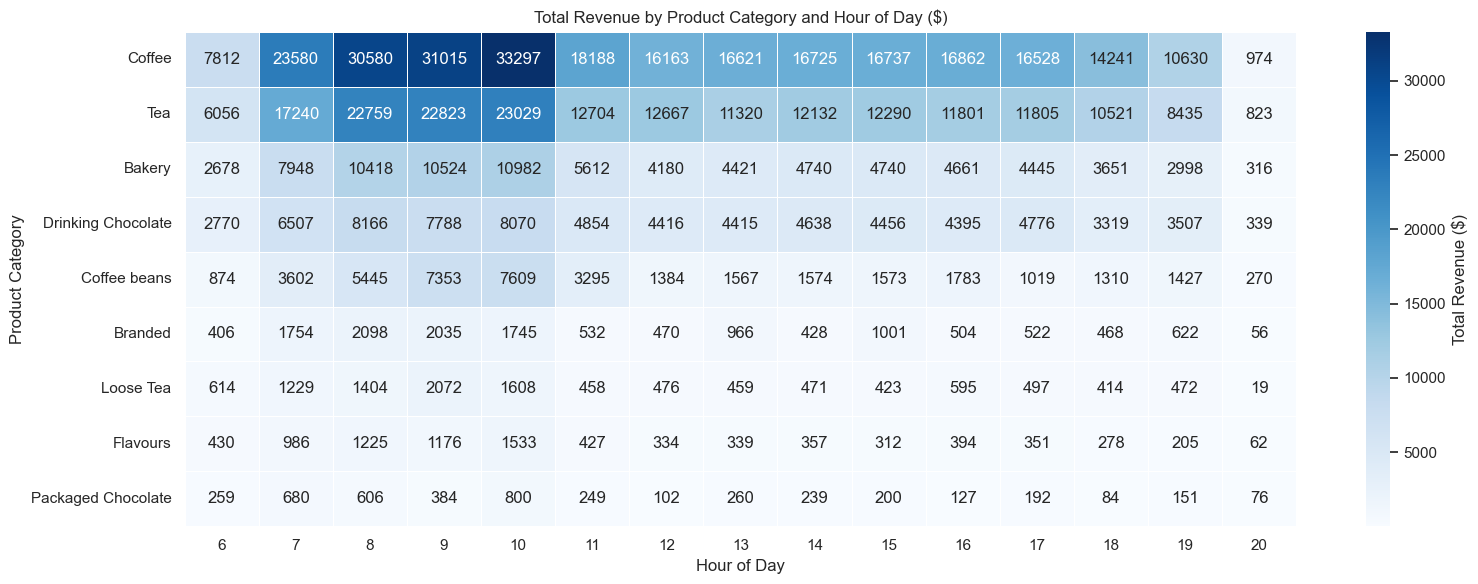

In [34]:
# Revenue by product category and hour
cat_hour = df.groupby(['product_category', 'Hour'])['Total_Bill'].sum().reset_index()
cat_hour_pivot = cat_hour.pivot(index='product_category', columns='Hour', values='Total_Bill').fillna(0).round(0)

# Sort rows by total revenue descending so the most important categories are at the top
cat_hour_pivot['Total'] = cat_hour_pivot.sum(axis=1)
cat_hour_pivot = cat_hour_pivot.sort_values('Total', ascending=False).drop(columns='Total')

print("=== REVENUE BY CATEGORY AND HOUR (TOP HOURS) ===")
print(cat_hour_pivot.iloc[:, :8].to_string())

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    cat_hour_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Total Revenue ($)'}
)

ax.set_title('Total Revenue by Product Category and Hour of Day ($)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Product Category')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

**Interpretation:** Three distinct patterns emerge from this heatmap. Coffee and Bakery are sharply morning-dependent, peaking hard between 8am and 10am and dropping off steeply after 11am. Their revenue is almost entirely concentrated in a three to four hour window, which means inventory and staffing for these two categories needs to be front-loaded at the start of every shift. Tea follows a similar but slightly flatter morning curve, with a modest secondary presence in the early afternoon. Drinking Chocolate is the most surprising finding: unlike every other beverage category, it maintains a relatively consistent revenue presence throughout the day rather than collapsing after the morning rush. This suggests Drinking Chocolate is not primarily a commuter grab-and-go product but something customers order when they have time to sit, which has different staffing and presentation implications than the morning-rush categories. Coffee beans and Branded merchandise show very low hourly values across all hours because their transactions are infrequent but high value, which is consistent with the top 10 products chart. The practical takeaway is that this chain is operationally two different businesses depending on the time of day: a high-volume morning rush machine before 11am, and a slower, more selective afternoon operation where Drinking Chocolate and take-home products carry a disproportionate share of the remaining revenue.

### Q4 Visualization 4: Interactive Revenue Drill-Down by Store, Category, and Hour

The three static charts above established the patterns: morning dominance, different operating hours by store, and category-level timing differences. This interactive chart lets you explore the exact numbers behind those patterns. Use the dropdown to switch between stores and see how the revenue distribution by category and hour shifts across locations.

In [35]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Build aggregations
# Chain-wide: revenue by hour
chain_hour = df.groupby('Hour')['Total_Bill'].sum().reset_index()
chain_hour.columns = ['Hour', 'Revenue']

# Per store: revenue by hour
store_hour = df.groupby(['store_location', 'Hour'])['Total_Bill'].sum().reset_index()

# Per store per category: revenue by hour
store_cat_hour = df.groupby(['store_location', 'product_category', 'Hour'])['Total_Bill'].sum().reset_index()

stores = ['Chain-wide', 'Astoria', "Hell's Kitchen", 'Lower Manhattan']
categories = df['product_category'].value_counts().index.tolist()

colors = {
    'Coffee': '#2e75b6',
    'Tea': '#2e8b57',
    'Bakery': '#9b59b6',
    'Drinking Chocolate': '#e74c3c',
    'Coffee beans': '#e67e22',
    'Flavours': '#f1c40f',
    'Loose Tea': '#27ae60',
    'Branded': '#7f8c8d',
    'Packaged Chocolate': '#795548'
}

hours = list(range(6, 21))

fig = go.Figure()

# Build one set of traces per store selection
# We will use updatemenus to toggle visibility

all_traces = []
trace_map = {}  # store_label -> list of trace indices

for store_label in stores:
    trace_map[store_label] = []

    for cat in categories:
        if store_label == 'Chain-wide':
            data = store_cat_hour[store_cat_hour['product_category'] == cat]
            rev_by_hour = data.groupby('Hour')['Total_Bill'].sum().reindex(hours, fill_value=0)
        else:
            data = store_cat_hour[
                (store_cat_hour['store_location'] == store_label) &
                (store_cat_hour['product_category'] == cat)
            ]
            rev_by_hour = data.set_index('Hour')['Total_Bill'].reindex(hours, fill_value=0)

        trace = go.Bar(
            x=hours,
            y=rev_by_hour.values,
            name=cat,
            marker_color=colors.get(cat, 'steelblue'),
            visible=(store_label == 'Chain-wide'),
            legendgroup=cat,
            showlegend=(store_label == 'Chain-wide'),
            hovertemplate=f'<b>{cat}</b><br>Hour: %{{x}}:00<br>Revenue: $%{{y:,.0f}}<extra></extra>'
        )
        fig.add_trace(trace)
        trace_map[store_label].append(len(fig.data) - 1)

# Total visible traces
n_traces = len(fig.data)
n_cats = len(categories)

# Dropdown buttons
buttons = []
for store_label in stores:
    visible = [False] * n_traces
    for idx in trace_map[store_label]:
        visible[idx] = True

    # Rebuild showlegend so legend only shows once
    showlegend_list = []
    for i in range(n_traces):
        showlegend_list.append(i in trace_map[store_label])

    buttons.append(dict(
        label=store_label,
        method='update',
        args=[
            {
                'visible': visible,
                'showlegend': showlegend_list
            },
            {
                'title': f'Revenue by Category and Hour: {store_label}'
            }
        ]
    ))

fig.update_layout(
    title='Revenue by Category and Hour: Chain-wide',
    xaxis=dict(
        title='Hour of Day',
        tickmode='array',
        tickvals=hours,
        ticktext=[f'{h}:00' for h in hours]
    ),
    yaxis=dict(title='Total Revenue ($)'),
    barmode='stack',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction='down',
        x=0.01,
        xanchor='left',
        y=1.12,
        yanchor='top',
        bgcolor='white',
        bordercolor='gray',
        font=dict(size=12)
    )],
    legend=dict(title='Product Category', orientation='v'),
    height=520,
    margin=dict(t=100)
)

fig.show()

**Interpretation:** The interactive chart confirms and extends the findings from the three static charts above. At the chain-wide level, the morning concentration is stark: the 8am to 10am window generates the overwhelming majority of daily revenue, with Coffee forming the base of every bar and Bakery and Tea stacking on top. Switching to individual stores reveals the operating hour differences the heatmap identified: Lower Manhattan's 6am bar is substantial while Astoria's is absent entirely, and Hell's Kitchen maintains a visible evening tail where the other two stores have already gone dark. The category stacking also makes the Drinking Chocolate finding from Visualization 3 easier to see at the store level: its segment is more evenly distributed across hours than Coffee or Bakery, particularly in the afternoon. The 49% of daily revenue generated before 11am is a chain-wide average, but the drill-down shows that number looks different depending on which store you are looking at. Lower Manhattan earns its morning revenue earlier than the other two stores, Astoria's morning window is compressed into a tighter band, and Hell's Kitchen is the only location where the afternoon and evening hours contribute enough to meaningfully shift the shape of the revenue day.

## Q5 Correlation and Predictive Analysis

**Question:** Unit price is the strongest predictor of Total_Bill at r = 0.69, meaning what a customer orders matters far more than how many items they buy. Can a simple linear regression model on unit price reliably predict transaction revenue, and what does that tell us about where this business should focus its pricing strategy?

We already established in the EDA that unit price and Total_Bill have the strongest linear relationship among the three numeric variables. Q5 builds on that finding by fitting a simple linear regression model and evaluating how well unit price alone can predict what a customer will spend.

### Q5 Visualization: Unit Price vs Total Bill, Linear Regression

=== LINEAR REGRESSION: Unit Price vs Total_Bill ===
Slope:        1.0900
Intercept:    0.9999
R:            0.6855
R-squared:    0.4700
P-value:      0.00e+00
Std Error:    0.0030

Regression equation: Total_Bill = 1.0900 x unit_price + (0.9999)


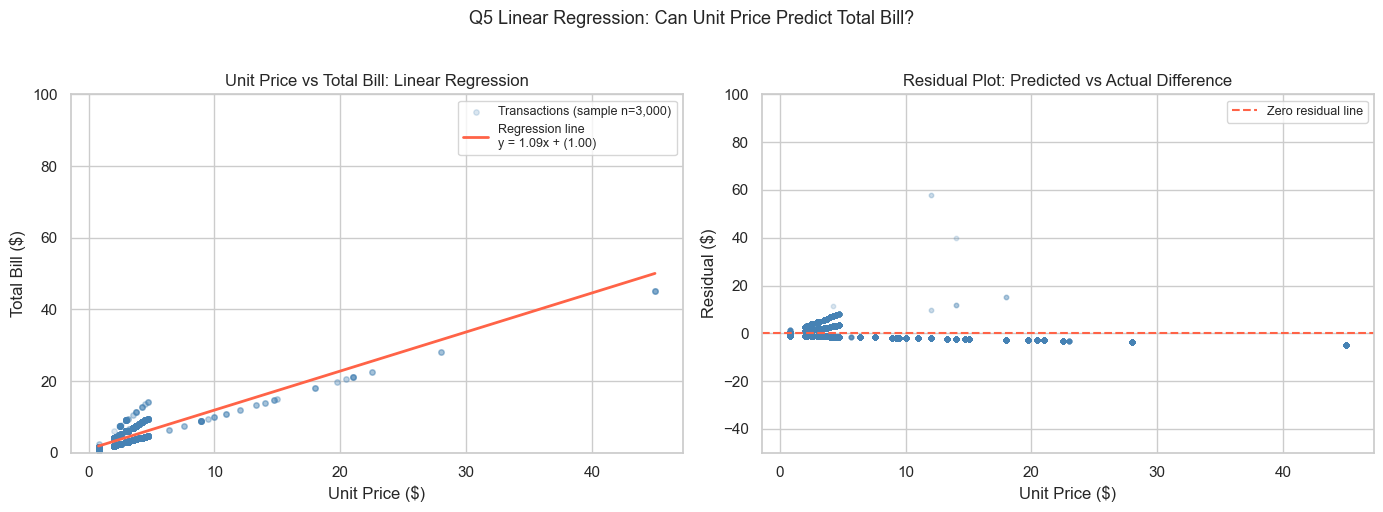

In [36]:
from scipy import stats
import numpy as np

# Fit linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['unit_price'], df['Total_Bill']
)

r_squared = r_value ** 2

print("=== LINEAR REGRESSION: Unit Price vs Total_Bill ===")
print(f"Slope:        {slope:.4f}")
print(f"Intercept:    {intercept:.4f}")
print(f"R:            {r_value:.4f}")
print(f"R-squared:    {r_squared:.4f}")
print(f"P-value:      {p_value:.2e}")
print(f"Std Error:    {std_err:.4f}")
print(f"\nRegression equation: Total_Bill = {slope:.4f} x unit_price + ({intercept:.4f})")

# Sample for scatter plot (full dataset is too dense to plot cleanly)
sample = df.sample(n=3000, random_state=42)

# Regression line points
x_line = np.linspace(df['unit_price'].min(), df['unit_price'].max(), 200)
y_line = slope * x_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter with regression line
axes[0].scatter(sample['unit_price'], sample['Total_Bill'],
                alpha=0.2, color='steelblue', s=15,
                label='Transactions (sample n=3,000)')
axes[0].plot(x_line, y_line, color='tomato', linewidth=2,
             label=f'Regression line\ny = {slope:.2f}x + ({intercept:.2f})')
axes[0].set_title('Unit Price vs Total Bill: Linear Regression')
axes[0].set_xlabel('Unit Price ($)')
axes[0].set_ylabel('Total Bill ($)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 100)

# Right: residuals plot
predicted = slope * df['unit_price'] + intercept
residuals = df['Total_Bill'] - predicted

axes[1].scatter(df['unit_price'], residuals,
                alpha=0.1, color='steelblue', s=10)
axes[1].axhline(0, color='tomato', linewidth=1.5, linestyle='--',
                label='Zero residual line')
axes[1].set_title('Residual Plot: Predicted vs Actual Difference')
axes[1].set_xlabel('Unit Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_ylim(-50, 100)
axes[1].legend(fontsize=9)

plt.suptitle('Q5 Linear Regression: Can Unit Price Predict Total Bill?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The regression equation this analysis produces is Total_Bill = 1.09 x unit_price + 1.00, with an R-squared of 0.47. This means unit price alone explains 47% of the variation in what a customer spends, which is a meaningful but incomplete predictor. The r = 0.69 correlation confirmed in the EDA is a moderate to strong linear relationship, and the regression line on the left chart shows it holds consistently across the everyday price range. However the residual plot on the right tells an equally important story: the spread of residuals widens significantly at higher unit prices, particularly for coffee beans and branded merchandise where transaction quantity varies more. This means the formula is reliable for predicting everyday drink purchases but less precise for premium products.

To make this concrete, plugging representative unit prices into the equation produces the following predictions:

In [37]:
# Prediction table: plugging representative unit prices into the regression equation
import pandas as pd

examples = pd.DataFrame({
    'Product Example': ['Flavour syrup', 'Small drip coffee', 'Latte', 'Drinking Chocolate', 'Coffee beans'],
    'Unit Price ($)': [0.80, 3.00, 4.50, 7.00, 22.00]
})

examples['Predicted Total Bill ($)'] = (slope * examples['Unit Price ($)'] + intercept).round(2)

print("=== REGRESSION PREDICTIONS: Unit Price to Total Bill ===")
print(examples.to_string(index=False))

=== REGRESSION PREDICTIONS: Unit Price to Total Bill ===
   Product Example  Unit Price ($)  Predicted Total Bill ($)
     Flavour syrup             0.8                      1.87
 Small drip coffee             3.0                      4.27
             Latte             4.5                      5.90
Drinking Chocolate             7.0                      8.63
      Coffee beans            22.0                     24.98


A Flavour syrup at $0.80 predicts a total bill of around $1.87. A Latte at $4.50 predicts $5.91. Coffee beans at $22.00 predict $24.98. These predictions are sensible and intuitive for everyday products, which confirms the formula is capturing the real relationship in the data. The wider residuals at the premium end simply reflect that a customer buying coffee beans might buy one bag or two, introducing variability that unit price alone cannot account for.

The business implication is direct. Because unit price is the dominant driver of Total_Bill and transaction quantity averages just 1.44 units per visit, the most effective lever for increasing revenue per transaction is pricing strategy on individual products rather than promotions designed to get customers to buy more items. Raising the price of high-volume products by even a small amount, or steering customers toward higher-priced categories like Drinking Chocolate, would have a more measurable impact on Total_Bill than any upselling strategy aimed at quantity.

## Q6 Ad Hoc Analysis: Are Hell's Kitchen and Lower Manhattan Selling to the Same Customer?

**Question:** Hell's Kitchen dominates coffee bean sales while Lower Manhattan leads in branded merchandise, but Hell's Kitchen barely sells branded products at all. If the three stores have the same menu, why do their customers shop so differently, and is Hell's Kitchen quietly functioning as a specialty coffee destination while the others operate more like general cafe retail stops?

This question follows directly from the cross-tabulation in Q3, which identified two anomalies: Hell's Kitchen generating 7.9% of its revenue from coffee beans versus 4.4% at Astoria and 4.9% at Lower Manhattan, and Lower Manhattan leading branded merchandise at 2.7% versus Hell's Kitchen's 0.8%. Q6 investigates whether these two anomalies together point to a fundamental difference in customer identity across the stores.

### Q6 Visualization: Customer Spending Profile by Store, Coffee Beans vs Branded Merchandise vs Everything Else

=== REVENUE SHARE BY CATEGORY AND STORE (%) ===
store_location      Astoria  Hell's Kitchen  Lower Manhattan
product_category                                            
Coffee beans           4.40            7.88             4.88
Branded                2.35            0.82             2.70
Bakery                11.45           11.58            12.31
Flavours               0.76            1.22             1.64
Tea                   29.21           27.36            27.76
Loose Tea              1.38            1.89             1.55
Drinking Chocolate    11.34            9.97             9.78
Coffee                38.64           38.57            38.68
Packaged Chocolate     0.47            0.72             0.70


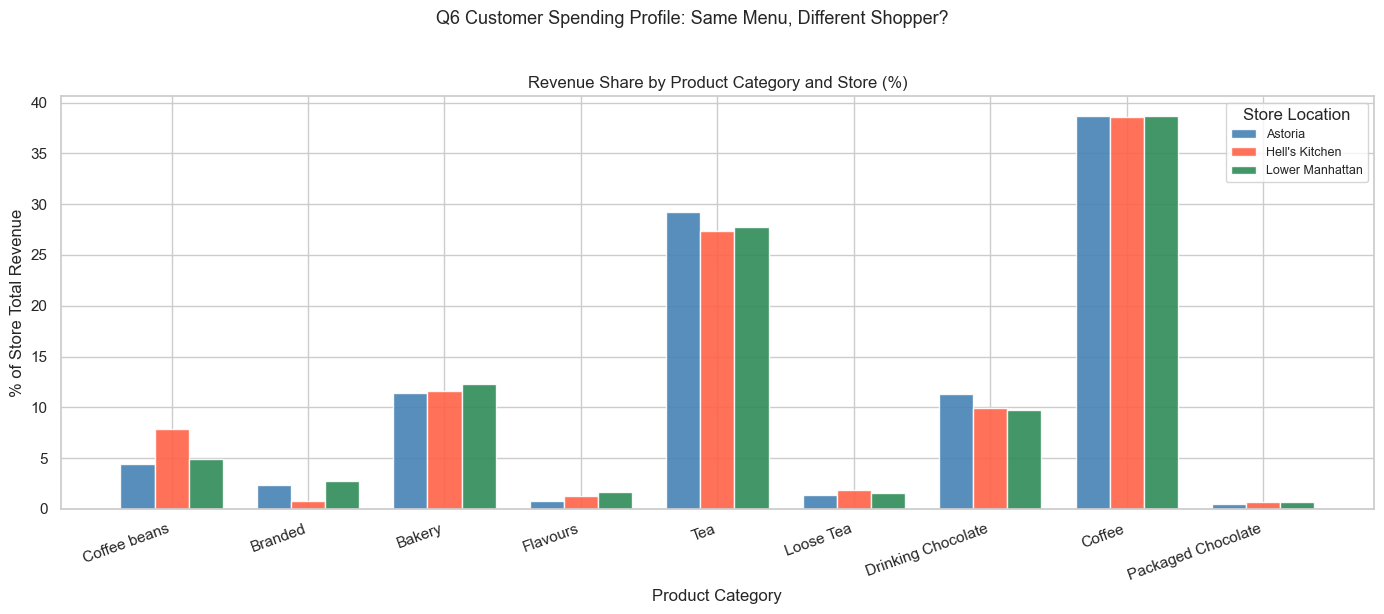

In [38]:
# Build a full revenue share profile for each store across all categories
total_per_store = df.groupby('store_location')['Total_Bill'].sum()

cat_store = df.groupby(['store_location', 'product_category'])['Total_Bill'].sum().reset_index()
cat_store['Revenue_Share'] = (cat_store['Total_Bill'] / 
                               cat_store['store_location'].map(total_per_store) * 100).round(2)

# Pivot for plotting
share_pivot = cat_store.pivot(index='product_category', 
                               columns='store_location', 
                               values='Revenue_Share').round(2)

# Sort by absolute difference between Hell's Kitchen and Lower Manhattan
share_pivot['HK_LM_diff'] = abs(share_pivot["Hell's Kitchen"] - share_pivot['Lower Manhattan'])
share_pivot = share_pivot.sort_values('HK_LM_diff', ascending=False).drop(columns='HK_LM_diff')

print("=== REVENUE SHARE BY CATEGORY AND STORE (%) ===")
print(share_pivot.round(2).to_string())

# Plot
stores = ['Astoria', "Hell's Kitchen", 'Lower Manhattan']
store_colors = ['steelblue', 'tomato', 'seagreen']
categories = share_pivot.index.tolist()
x = range(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, (store, color) in enumerate(zip(stores, store_colors)):
    offset = (i - 1) * width
    bars = ax.bar([xi + offset for xi in x], share_pivot[store],
                  width=width, label=store, color=color,
                  edgecolor='white', alpha=0.9)

ax.set_title('Revenue Share by Product Category and Store (%)')
ax.set_xlabel('Product Category')
ax.set_ylabel('% of Store Total Revenue')
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha='right')
ax.legend(title='Store Location', fontsize=9)

plt.suptitle('Q6 Customer Spending Profile: Same Menu, Different Shopper?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The revenue share chart makes the two anomalies from Q3 impossible to ignore when viewed side by side. Hell's Kitchen allocates 7.9% of its total revenue to coffee beans, nearly double Astoria's 4.4% and significantly above Lower Manhattan's 4.9%. At the same time Hell's Kitchen generates only 0.8% of its revenue from branded merchandise, while Lower Manhattan generates 2.7% and Astoria 2.35%. These two categories move in opposite directions at the same two stores, and that is not a coincidence.

The pattern points to two distinct customer identities hiding behind identical transaction volumes. Hell's Kitchen appears to attract a specialty coffee customer: someone who comes in not just for a drink but to purchase whole beans for home brewing, suggesting a level of coffee engagement that goes beyond the typical cafe visit. Lower Manhattan by contrast attracts a customer who buys branded merchandise, which in a cafe context typically means mugs, tumblers, or branded retail items: the kind of purchase associated with office workers buying gifts, souvenirs, or treating the cafe as a lifestyle brand rather than just a coffee source.

For every other major category including Coffee, Tea, Bakery, and Drinking Chocolate, the three stores are remarkably similar in their revenue share, which means the divergence is concentrated and deliberate rather than spread randomly across the menu. Hell's Kitchen is not just a coffee shop. It is quietly functioning as a specialty coffee destination. Lower Manhattan is not just a coffee shop either. It is functioning as a branded retail stop that happens to serve coffee.

## Q7 Ad Hoc Analysis: Flavours, The Most Transacted Near-Invisible Category

**Question:** Flavour syrups appear in 6,790 transactions, more than coffee beans, loose tea, and packaged chocolate combined, yet generate only $8,409 in revenue at $0.80 each. Are customers actually paying for these add-ons, or are they being absorbed into other transactions and effectively given away, making Flavours the most transacted near-invisible category in the entire dataset?

This question follows from the EDA summary in section 2.9, which flagged Flavours as the most deceptive category in the dataset. Q7 investigates the revenue gap between transaction volume and actual revenue contribution, and asks what that gap means for the business.

### Q7 Visualization 1: Flavours vs Other Categories, Transactions vs Revenue

=== CATEGORY SUMMARY: TRANSACTIONS VS REVENUE ===
  product_category  Transactions  Total_Revenue  Avg_Ticket  Revenue_per_Transaction
            Coffee         58416      269952.45        4.62                     4.62
               Tea         45449      196405.95        4.32                     4.32
            Bakery         22796       82315.64        3.61                     3.61
Drinking Chocolate         11468       72416.00        6.31                     6.31
          Flavours          6790        8408.80        1.24                     1.24
      Coffee beans          1753       40085.25       22.87                    22.87
         Loose Tea          1210       11213.60        9.27                     9.27
           Branded           747       13607.00       18.22                    18.22
Packaged Chocolate           487        4407.64        9.05                     9.05


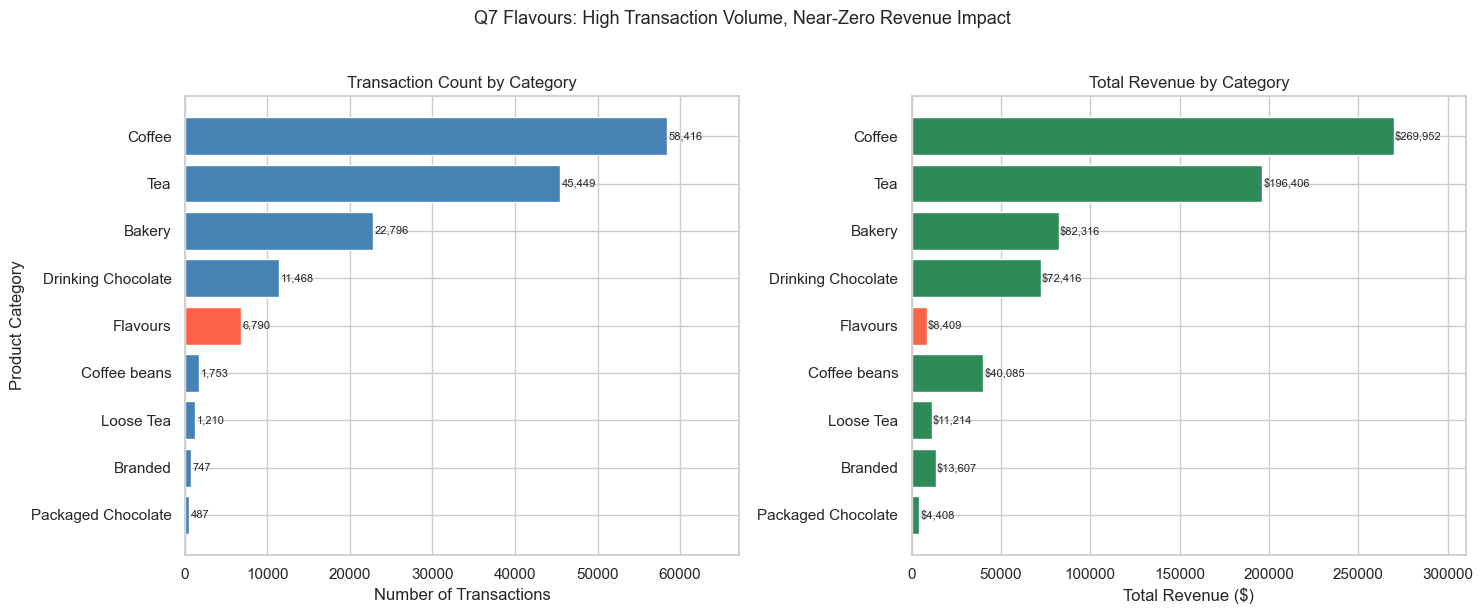

In [39]:
# Build transactions vs revenue comparison across all categories
cat_summary = df.groupby('product_category').agg(
    Transactions=('transaction_id', 'count'),
    Total_Revenue=('Total_Bill', 'sum'),
    Avg_Ticket=('Total_Bill', 'mean')
).round(2).reset_index()

cat_summary['Revenue_per_Transaction'] = (cat_summary['Total_Revenue'] / 
                                           cat_summary['Transactions']).round(2)

# Sort by transactions descending
cat_summary = cat_summary.sort_values('Transactions', ascending=False).reset_index(drop=True)

print("=== CATEGORY SUMMARY: TRANSACTIONS VS REVENUE ===")
print(cat_summary.to_string(index=False))

# Highlight Flavours in both panels
colors_txn = ['tomato' if cat == 'Flavours' else 'steelblue' 
              for cat in cat_summary['product_category']]
colors_rev = ['tomato' if cat == 'Flavours' else 'seagreen' 
              for cat in cat_summary['product_category']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: transactions by category
axes[0].barh(cat_summary['product_category'][::-1], 
             cat_summary['Transactions'][::-1],
             color=colors_txn[::-1], edgecolor='white')
for i, val in enumerate(cat_summary['Transactions'][::-1]):
    axes[0].text(val + 200, i, f'{val:,}', va='center', fontsize=8)
axes[0].set_title('Transaction Count by Category')
axes[0].set_xlabel('Number of Transactions')
axes[0].set_ylabel('Product Category')
axes[0].set_xlim(0, cat_summary['Transactions'].max() * 1.15)

# Right: total revenue by category
axes[1].barh(cat_summary['product_category'][::-1],
             cat_summary['Total_Revenue'][::-1],
             color=colors_rev[::-1], edgecolor='white')
for i, val in enumerate(cat_summary['Total_Revenue'][::-1]):
    axes[1].text(val + 500, i, f'${val:,.0f}', va='center', fontsize=8)
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, cat_summary['Total_Revenue'].max() * 1.15)

plt.suptitle('Q7 Flavours: High Transaction Volume, Near-Zero Revenue Impact',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The side by side chart makes the Flavours anomaly immediately visible. On the left panel, Flavours ranks fifth in transaction count with 6,790 transactions, sitting above Coffee beans at 1,753, Loose Tea at 1,210, Branded at 747, and Packaged Chocolate at 487. By transaction volume alone, Flavours looks like a meaningful part of the business. The right panel tells a completely different story. In total revenue, Flavours is last, generating only $8,409 across all 6,790 transactions at an average of $1.24 per transaction. Coffee beans, which have less than a quarter of Flavours' transaction count, generate $40,085 in revenue. Packaged Chocolate, with 487 transactions, generates $4,407, meaning it produces more than half of Flavours' revenue with 7% of the transactions.

The reason is structural. Flavour syrups are priced at $0.80 each and function as drink add-ons rather than standalone purchases. A customer ordering a vanilla latte is recorded as one coffee transaction and one Flavours transaction, but the syrup contributes almost nothing to the bill. At $0.80, Flavours is the only category in the dataset priced below $1.00, and its average ticket of $1.24 confirms that even when customers buy two syrups the total remains negligible. The business is processing thousands of Flavours transactions that consume the same operational overhead as any other transaction while contributing less than 1.2% of total chain revenue. Whether that is intentional positioning or a pricing oversight is the most interesting question this dataset raises.

### Q7 Visualization 2: Monthly Revenue Growth by Category

Every major category grew from January to June 2023. The question is whether Flavours grew at the same rate as the rest of the business or whether its near-invisible revenue contribution stayed flat while everything else accelerated. A stagnant Flavours line would suggest the category is not just low-revenue but also failing to benefit from the chain's overall growth momentum.

=== MONTHLY REVENUE BY CATEGORY ===
product_category   Coffee      Tea   Bakery  Drinking Chocolate  Coffee beans  Branded  Flavours
Jan               31257.0  22622.0   9536.0              8338.0        5245.0   1890.0     974.0
Feb               29269.0  21733.0   9039.0              8132.0        4078.0   1235.0     930.0
Mar               38304.0  27911.0  11903.0             10254.0        5256.0   1801.0    1172.0
Apr               45971.0  33357.0  14022.0             12267.0        6825.0   2379.0    1418.0
May               60363.0  44540.0  18566.0             16320.0        8769.0   2889.0    1906.0
Jun               64789.0  46243.0  19251.0             17106.0        9913.0   3413.0    2008.0


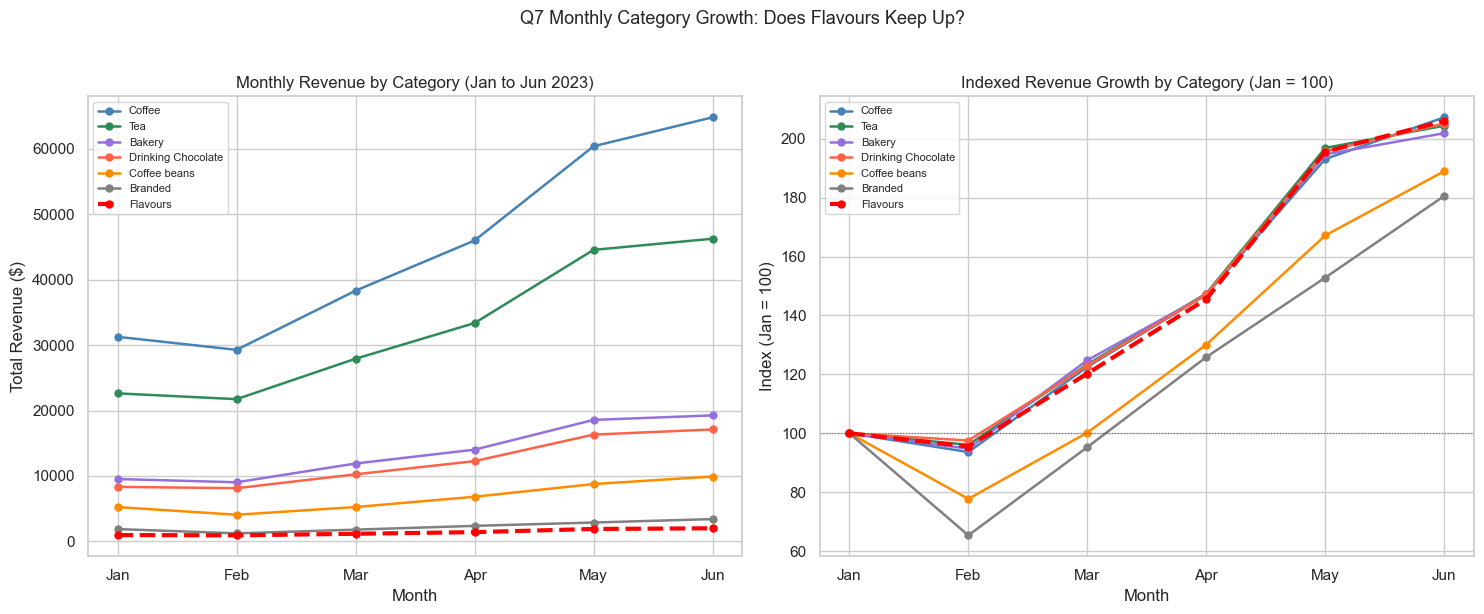

In [40]:
# Monthly revenue by category
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun'}

cat_monthly = df.groupby(['Month', 'product_category'])['Total_Bill'].sum().reset_index()
cat_monthly['Month Name'] = cat_monthly['Month'].map(month_names)

# Pivot
cat_monthly_pivot = cat_monthly.pivot(index='Month', 
                                       columns='product_category', 
                                       values='Total_Bill').fillna(0)
cat_monthly_pivot.index = [month_names[m] for m in cat_monthly_pivot.index]

# Focus on top 6 categories by total revenue for readability
top_cats = df.groupby('product_category')['Total_Bill'].sum().nlargest(6).index.tolist()

# Always include Flavours even if not in top 6
if 'Flavours' not in top_cats:
    top_cats.append('Flavours')

plot_data = cat_monthly_pivot[top_cats]

print("=== MONTHLY REVENUE BY CATEGORY ===")
print(plot_data.round(0).to_string())

# Color Flavours differently
cat_colors = {
    'Coffee': 'steelblue',
    'Tea': 'seagreen',
    'Bakery': 'mediumpurple',
    'Drinking Chocolate': 'tomato',
    'Coffee beans': 'darkorange',
    'Branded': 'gray',
    'Flavours': 'red'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: absolute revenue by month per category
for cat in top_cats:
    lw = 3 if cat == 'Flavours' else 1.8
    ls = '--' if cat == 'Flavours' else '-'
    axes[0].plot(plot_data.index, plot_data[cat],
                 marker='o', linewidth=lw, linestyle=ls,
                 color=cat_colors.get(cat, 'steelblue'),
                 label=cat, markersize=5)

axes[0].set_title('Monthly Revenue by Category (Jan to Jun 2023)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].legend(fontsize=8, loc='upper left')

# Right: indexed growth (Jan = 100) to compare growth rates fairly
indexed = plot_data.div(plot_data.iloc[0]) * 100

for cat in top_cats:
    lw = 3 if cat == 'Flavours' else 1.8
    ls = '--' if cat == 'Flavours' else '-'
    axes[1].plot(indexed.index, indexed[cat],
                 marker='o', linewidth=lw, linestyle=ls,
                 color=cat_colors.get(cat, 'steelblue'),
                 label=cat, markersize=5)

axes[1].axhline(100, color='black', linewidth=0.8, linestyle=':', alpha=0.5)
axes[1].set_title('Indexed Revenue Growth by Category (Jan = 100)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Index (Jan = 100)')
axes[1].legend(fontsize=8, loc='upper left')

plt.suptitle('Q7 Monthly Category Growth: Does Flavours Keep Up?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The left chart confirms that every major category grew meaningfully from January to June, with Coffee, Tea, and Bakery all riding the same growth wave identified in Q2. The right chart is more revealing because it puts every category on equal footing by indexing January revenue to 100. From this view, Flavours does not collapse or disappear, it actually tracks loosely with the rest of the business in percentage terms. However that growth is almost meaningless in absolute terms because Flavours started so low. Growing from $1,200 in January to $1,800 in June is a 50% increase on paper but contributes nothing material to chain revenue.

The more important finding from the indexed chart is Coffee beans, which shows the steepest growth trajectory of any category across the six months. This is consistent with the Q3 and Q6 findings about Hell's Kitchen functioning as a specialty coffee destination: as the chain grew through spring and into summer, the customers driving the most revenue growth were the ones buying whole beans to take home, not the ones adding a flavour syrup to their latte. Flavours grew with the business but remained invisible within it, which is the most precise summary of its role in this dataset.